# PowerCo — Task 2: Exploratory Data Analysis

**Client:** PowerCo, a major gas and electricity utility supplying corporate customers.
**Business problem:** significant churn in the SME segment. The hypothesis to be tested is that
**price sensitivity** is a major driver of that churn, and that a targeted 20% discount could be
used to retain the customers most at risk.

**Purpose of this notebook.** Before any feature engineering or modelling, we need to understand
what the client has actually sent us. This notebook works through a repeatable EDA framework:

| Step | Question it answers |
|---|---|
| 1. Structure | How many rows/columns, what is the grain of each table, how do they join? |
| 2. Data types | Does each column's storage type match its commercial meaning? |
| 3. Completeness | Where are the nulls, and where are values *encoded* as missing? |
| 4. Descriptive statistics | How do values vary — centre, spread, cardinality? |
| 5. Distributions | What shape does each variable take, and does it differ by churn? |
| 6. Findings | What does this imply for cleaning, feature engineering and modelling? |

**Datasets provided**

1. `client_data.csv` — historical customer data (usage, forecasts, margins, contract dates). The
   **churn indicator** is delivered as the `churn` column inside this file rather than as a
   separate third file.
2. `price_data.csv` — historical variable ("var", energy) and fixed ("fix", power) prices at
   monthly points in time, split across three tariff periods.

## Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

# Show all columns when printing wide dataframes
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can
work with them in Python. It is assumed the CSV files sit in the same folder as this notebook; if
not, adjust the path in `read_csv` accordingly.

In [2]:
client_df = pd.read_csv('../data/raw/client_data.csv')
price_df = pd.read_csv('../data/raw/price_data.csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## 1. Structure and granularity

Before looking at any individual column, establish the shape of each table, what one row
represents, and whether the two tables actually join.

In [5]:
print(f"client_data : {client_df.shape[0]:,} rows x {client_df.shape[1]} columns")
print(f"price_data  : {price_df.shape[0]:,} rows x {price_df.shape[1]} columns")

client_data : 14,606 rows x 26 columns
price_data  : 193,002 rows x 8 columns


In [6]:
# What does one row represent in each table?
print("client_df -- rows:", len(client_df), "| unique ids:", client_df["id"].nunique())
print("           -> one row per client company\n")

print("price_df  -- rows:", len(price_df),
      "| unique ids:", price_df["id"].nunique(),
      "| unique dates:", price_df["price_date"].nunique())
print("           -> one row per client per month (a panel / long format table)")
print("\nDuplicate (id, price_date) pairs:", price_df.duplicated(subset=["id", "price_date"]).sum())

client_df -- rows: 14606 | unique ids: 14606
           -> one row per client company

price_df  -- rows: 193002 | unique ids: 16096 | unique dates: 12
           -> one row per client per month (a panel / long format table)

Duplicate (id, price_date) pairs: 0


`client_data` is a **wide, one-row-per-customer** table. `price_data` is a **long panel**, one row
per customer per month, with no duplicated `(id, price_date)` pairs. Any price information must
therefore be *aggregated up to customer level* before it can be joined to the client table — that
is the core of the feature-engineering work in the next task.

In [7]:
# Does the price panel cover every client we need to model?
client_ids = set(client_df["id"])
price_ids  = set(price_df["id"])

print("Clients in client_data              :", len(client_ids))
print("Clients in price_data               :", len(price_ids))
print("Clients in BOTH                     :", len(client_ids & price_ids))
print("Clients with NO price history       :", len(client_ids - price_ids))
print("Price ids with NO client record     :", len(price_ids - client_ids))

Clients in client_data              : 14606
Clients in price_data               : 16096
Clients in BOTH                     : 14606
Clients with NO price history       : 0
Price ids with NO client record     : 1490


In [8]:
# Time coverage of the price panel
price_df["price_date"] = pd.to_datetime(price_df["price_date"])
print("Price date range:", price_df["price_date"].min().date(), "to", price_df["price_date"].max().date())
print("Distinct months :", price_df["price_date"].nunique(), "\n")

months_per_client = price_df.groupby("id").size()
print("Months of price history per client:")
print(months_per_client.value_counts().sort_index(ascending=False).to_frame("n_clients"))

Price date range: 2015-01-01 to 2015-12-01
Distinct months : 12 

Months of price history per client:
    n_clients
12      15990
11         83
10         11
9           6
8           3
7           3


**Observations**

* Every one of the 14,606 clients we need to model has price history — no coverage gap on the join.
* The price file contains ~1,490 *extra* companies that do not appear in the client table. These
  are not modellable (no churn label) and will drop out on an inner/left join from the client side.
* The panel covers **calendar year 2015 only, at monthly granularity** (12 reference dates). Most
  clients have the full 12 months, but a small minority have 7–11 months. Any per-client price
  aggregate (mean, variance, Dec-vs-Jan difference) must therefore be computed defensively rather
  than assuming 12 observations.

---

## 2. Data types

The data types dictate how we transform and engineer features. To get an overview of the data
types within a dataframe, use the `info()` method — then check each type against the *commercial
meaning* given in the data description document.

In [9]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [10]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  str           
 1   price_date          193002 non-null  datetime64[us]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 11.8 MB


### Auditing dtypes against commercial meaning

`info()` tells us how pandas *stored* each column, not whether that storage is correct. Comparing
against the data description surfaces three mismatches worth fixing:

| Column(s) | Stored as | Commercial meaning | Action |
|---|---|---|---|
| `date_activ`, `date_end`, `date_modif_prod`, `date_renewal` | text | dates | cast to `datetime64` |
| `has_gas` | text `'t'` / `'f'` | boolean flag | cast to boolean / 0-1 |
| `churn` | `int64` | binary target | correct, but treat as categorical for grouping |
| `channel_sales`, `origin_up` | text | hashed categorical codes | correct — keep as categorical |
| `nb_prod_act`, `num_years_antig` | `int64` | counts | correct, low-cardinality discrete |

Note also that the data description lists an `activity_new` field (category of company activity)
which is **not present** in the delivered `client_data.csv`. Worth raising with the client, but
not a blocker.

In [11]:
date_columns = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]
for column in date_columns:
    client_df[column] = pd.to_datetime(client_df[column])

# 't'/'f' text flag -> proper boolean
client_df["has_gas"] = client_df["has_gas"].map({"t": True, "f": False})

client_df[date_columns + ["has_gas"]].dtypes

date_activ         datetime64[us]
date_end           datetime64[us]
date_modif_prod    datetime64[us]
date_renewal       datetime64[us]
has_gas                      bool
dtype: object

In [12]:
# Sanity-check the date ranges now that they are real dates
client_df[date_columns].agg(["min", "max"]).T

,min,max
date_activ,2003-05-09,2014-09-01
date_end,2016-01-28,2017-06-13
date_modif_prod,2003-05-09,2016-01-29
date_renewal,2013-06-26,2016-01-28


The date ranges make business sense and confirm the framing of the target:

* `date_activ` spans 2003–2014 — a mature book of business, not a recent cohort.
* `date_end` runs **Jan 2016 – Jun 2017**, and `date_renewal` runs up to **Jan 2016**. The data
  description defines `churn` as *"has the client churned over the next 3 months"*, which is
  consistent with a snapshot taken at the start of 2016, immediately after the 2015 price panel.
  The price data therefore sits *before* the churn outcome window — no obvious leakage.

In [13]:
# Explicit column groups — used throughout the rest of the notebook
target_col = "churn"
id_col = "id"
categorical_cols = ["channel_sales", "origin_up"]
boolean_cols = ["has_gas"]
numeric_cols = [
    "cons_12m", "cons_gas_12m", "cons_last_month",
    "forecast_cons_12m", "forecast_cons_year", "forecast_discount_energy",
    "forecast_meter_rent_12m", "forecast_price_energy_off_peak",
    "forecast_price_energy_peak", "forecast_price_pow_off_peak",
    "imp_cons", "margin_gross_pow_ele", "margin_net_pow_ele",
    "nb_prod_act", "net_margin", "num_years_antig", "pow_max",
]
price_var_cols = ["price_off_peak_var", "price_peak_var", "price_mid_peak_var"]
price_fix_cols = ["price_off_peak_fix", "price_peak_fix", "price_mid_peak_fix"]

print(f"{len(numeric_cols)} numeric, {len(categorical_cols)} categorical, "
      f"{len(boolean_cols)} boolean, {len(date_columns)} date, 1 id, 1 target "
      f"= {len(numeric_cols)+len(categorical_cols)+len(boolean_cols)+len(date_columns)+2} columns")

17 numeric, 2 categorical, 1 boolean, 4 date, 1 id, 1 target = 26 columns


---

## 3. Completeness — nulls and encoded missingness

A `isna()` count alone is misleading here. This dataset encodes missing categorical values as the
literal **string `"MISSING"`**, which pandas reads as a perfectly valid value.

In [14]:
print("Null values in client_data:", client_df.isna().sum().sum())
print("Null values in price_data :", price_df.isna().sum().sum())

Null values in client_data: 0
Null values in price_data : 0


In [15]:
# Encoded missingness: the literal string "MISSING"
for col in categorical_cols:
    n = (client_df[col] == "MISSING").sum()
    print(f"{col:<15} '{'MISSING'}' in {n:>5,} rows ({n/len(client_df)*100:5.1f}%)")

channel_sales   'MISSING' in 3,725 rows ( 25.5%)
origin_up       'MISSING' in    64 rows (  0.4%)


In [16]:
# Zero-inflation: for several columns a 0 is a structural "not applicable", not a measurement
zero_share = (client_df[numeric_cols] == 0).mean().mul(100).round(1).sort_values(ascending=False)
zero_share.to_frame("percent_zero").head(12)

,percent_zero
forecast_discount_energy,96.5
cons_gas_12m,82.1
forecast_price_energy_peak,48.1
imp_cons,42.2
forecast_cons_year,42.1
cons_last_month,34.1
forecast_meter_rent_12m,5.0
forecast_cons_12m,2.1
net_margin,1.3
margin_gross_pow_ele,1.1


**Observations**

* There are **no `NaN` values anywhere** in either file — but that is not the same as complete data.
* `channel_sales` is `"MISSING"` for **25.5%** of clients and `origin_up` for 0.4%. These must be
  treated as their own category (or explicitly imputed), never silently trusted as a real code.
* Several numeric columns are heavily **zero-inflated**, and the zeros are structural rather than
  erroneous:
  * `forecast_discount_energy` = 0 for 96.5% — almost nobody currently has a discount. This is the
    single most important context for the case: the proposed 20% discount would be a *new*
    intervention for nearly the whole base.
  * `cons_gas_12m` = 0 for 82.1% — consistent with only 18.1% of clients having `has_gas = True`.
  * `forecast_price_energy_peak` = 0 for 48.1% and `imp_cons` / `forecast_cons_year` for ~42% —
    these clients are on tariffs with no peak period, so the "price" is genuinely zero, not unknown.

In [17]:
# Cross-check: is cons_gas_12m == 0 explained by has_gas?
pd.crosstab(client_df["has_gas"], client_df["cons_gas_12m"] > 0,
            rownames=["has_gas"], colnames=["gas consumption > 0"])

gas consumption > 0,False,True
has_gas,,
False,11902,53
True,92,2559


In [18]:
# Redundancy check: gross vs net power margin
identical = (client_df["margin_gross_pow_ele"] == client_df["margin_net_pow_ele"]).mean()
print(f"margin_gross_pow_ele == margin_net_pow_ele in {identical*100:.2f}% of rows")
print("Correlation:", client_df[["margin_gross_pow_ele", "margin_net_pow_ele"]].corr().iloc[0, 1].round(6))

margin_gross_pow_ele == margin_net_pow_ele in 99.99% of rows
Correlation: 0.999914


`has_gas` and non-zero gas consumption line up almost perfectly, confirming the zeros are structural.

`margin_gross_pow_ele` and `margin_net_pow_ele` are **identical in 99.99% of rows** and perfectly
correlated. They carry the same information; keeping both would just add collinearity to a model.

---

## 4. The churn target

The churn indicator is the `churn` column of `client_data.csv`: 1 if the client churned over the
next 3 months, 0 otherwise.

In [19]:
client_df["churn"].value_counts(dropna=False)

churn
0    13187
1     1419
Name: count, dtype: int64

In [20]:
client_df["churn"].value_counts(normalize=True, dropna=False) * 100

churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64

The churn target is **imbalanced**: approximately **90.3%** of customers did not churn, while
**9.7%** churned. This will affect model evaluation — accuracy alone would be misleading, since a
model that predicts "no churn" for everyone would score 90.3%. Metrics such as **recall,
precision, F1-score and the confusion matrix** will be important for assessing how well the model
identifies the smaller group of customers who actually churned.

It also matters commercially: a blanket 20% discount would be applied to ~90% of customers who
were never going to leave, destroying margin. Targeting is the whole point of the exercise.

---

## 5. Descriptive statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()`
method. This tells us the basic statistical properties of each column — and how many values feature
within a column, which starts to build a picture of what the data represents.

In [21]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912,2016-07-27 20:48:26.422018,2013-01-02 12:29:10.951663,2015-07-21 06:59:00.353279,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


In [22]:
client_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,14606,14606,24011ae4ebbe3035111d65fa7c15bc57,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_sales,14606,8,foosdfpfkusacimwkcsosbicdxkicaua,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons_12m,14606.0,NaN,NaN,NaN,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,NaN,NaN,NaN,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,NaN,NaN,NaN,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,NaN,NaN,NaN,2011-01-28 07:54:18.879912,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,NaN,NaN,NaN,2016-07-27 20:48:26.422018,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,NaN,NaN,NaN,2013-01-02 12:29:10.951663,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,NaN,NaN,NaN,2015-07-21 06:59:00.353279,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,NaN,NaN,NaN,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531


In [23]:
price_df.describe()

,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


In [24]:
price_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,193002,16096,038af19179925da21a25619c5a24b745,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_date,193002,NaN,NaN,NaN,2015-06-16 12:50:49.933161,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,NaN,NaN,NaN,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,NaN,NaN,NaN,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,NaN,NaN,NaN,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,NaN,NaN,NaN,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,NaN,NaN,NaN,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,NaN,NaN,NaN,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


### Cardinality — how many distinct values does each column take?

This distinguishes genuine continuous measurements from discrete codes and near-constant columns.

In [25]:
card = pd.DataFrame({
    "n_unique": client_df.nunique(),
    "pct_unique": (client_df.nunique() / len(client_df) * 100).round(2),
    "dtype": client_df.dtypes.astype(str),
})
card.sort_values("n_unique")

,n_unique,pct_unique,dtype
churn,2,0.01,int64
has_gas,2,0.01,bool
origin_up,6,0.04,str
channel_sales,8,0.05,str
nb_prod_act,10,0.07,int64
forecast_discount_energy,12,0.08,float64
num_years_antig,13,0.09,int64
forecast_price_pow_off_peak,41,0.28,float64
forecast_price_energy_peak,329,2.25,float64
date_end,368,2.52,datetime64[us]


### Spread and shape of the numeric columns

`describe()` gives the centre and spread; adding **skew** and the **max/median ratio** shows how
extreme the right tails are.

In [26]:
summary = client_df[numeric_cols].describe().T
summary["skew"] = client_df[numeric_cols].skew()
summary["max_over_median"] = (summary["max"] / summary["50%"].replace(0, np.nan)).round(1)
summary[["mean", "std", "min", "50%", "max", "skew", "max_over_median"]].round(2) \
       .sort_values("skew", ascending=False)

,mean,std,min,50%,max,skew,max_over_median
net_margin,189.26,311.80,0.0,112.53,24570.65,36.57,218.3
forecast_cons_year,1399.76,3247.79,0.0,314.00,175375.00,16.59,558.5
imp_cons,152.79,341.37,0.0,37.39,15042.79,13.20,402.3
cons_gas_12m,28092.38,162973.06,0.0,0.00,4154590.00,9.60,NaN
nb_prod_act,1.29,0.71,1.0,1.00,32.00,8.64,32.0
forecast_cons_12m,1868.61,2387.57,0.0,1112.88,82902.83,7.16,74.5
cons_last_month,16090.27,64364.20,0.0,792.50,771203.00,6.39,973.1
cons_12m,159220.29,573465.26,0.0,14115.50,6207104.00,6.00,439.7
pow_max,18.14,13.53,3.3,13.86,320.00,5.79,23.1
forecast_discount_energy,0.97,5.11,0.0,0.00,30.00,5.16,NaN


**Observations**

* Almost every consumption, forecast and margin column is **severely right-skewed** (skew 4–37).
  `net_margin` has a skew of ~37; `cons_12m` has a median of 14,116 kWh but a maximum of
  6.2 million — a ratio of ~440x. The mean is far above the median throughout, so **the mean is not
  a representative customer**.
* The book is a small number of very large industrial sites sitting alongside a long tail of small
  SMEs. Any model will need **log transforms and/or outlier treatment** on these columns, and
  metrics should be reported on the median rather than the mean.
* `nb_prod_act` has a max of 32 against a median of 1; `pow_max` a max of 320 kVA against a median
  of 13.9 kVA. These are plausible real values for large sites, not data errors — they should be
  capped or transformed, not deleted.
* No negative values appear anywhere, which is consistent with consumption and price semantics.

### Price data — variable (energy) vs fixed (power) prices

In [27]:
price_summary = price_df[price_var_cols + price_fix_cols].describe().T
price_summary["percent_zero"] = (price_df[price_var_cols + price_fix_cols] == 0).mean().mul(100).round(1)
price_summary[["mean", "std", "min", "50%", "max", "percent_zero"]].round(4)

,mean,std,min,50%,max,percent_zero
price_off_peak_var,0.1410,0.0250,0.0,0.1460,0.2807,0.2
price_peak_var,0.0546,0.0499,0.0,0.0855,0.2298,45.0
price_mid_peak_var,0.0305,0.0363,0.0,0.0000,0.1141,58.5
price_off_peak_fix,43.3345,5.4103,0.0,44.2669,59.4447,0.8
price_peak_fix,10.6229,12.8419,0.0,0.0000,36.4907,58.5
price_mid_peak_fix,6.4100,7.7736,0.0,0.0000,17.4582,58.5


**Observations**

* The two price families are on completely different scales: **variable/energy prices** sit around
  €0.14/kWh, while **fixed/power prices** sit around €43 per period. They must never be averaged
  together.
* The **off-peak period is the one that is always active**: only 0.2% of rows have a zero off-peak
  energy price. By contrast `price_peak_var` is zero in 45% of rows and every mid-peak column is
  zero in 58.5% of rows.
* This means many customers are on a **single-period (off-peak-only) tariff**. A "mid-peak price of
  zero" is a *tariff structure* signal, not a cheap price — a useful feature in its own right, but
  a trap if fed to a model as a continuous price.

---

## 6. Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib`
and `seaborn`. We highly recommend you use these, or at least be familiar with them because they
are ubiquitous!

Below are the helper functions provided in the starter notebook, which we use throughout.

In [28]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(), 1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x() + p.get_width() / 2) * pad - 0.05, (p.get_y() + p.get_height() / 2) * pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

### 6.1 Churn status across the whole customer base

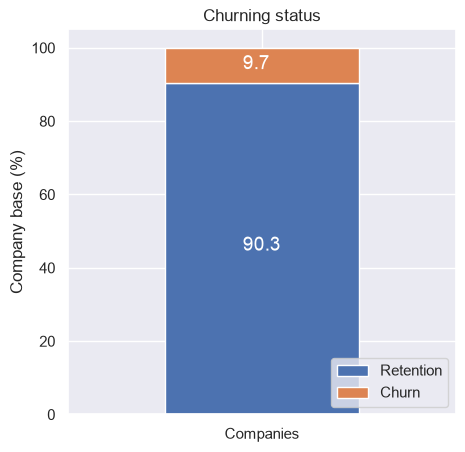

In [29]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

About **10 in every 100 SME customers churn within the 3-month window**. Everything that follows
asks the same question: which slices of the base sit meaningfully above or below that 9.7% baseline?

### 6.2 Consumption

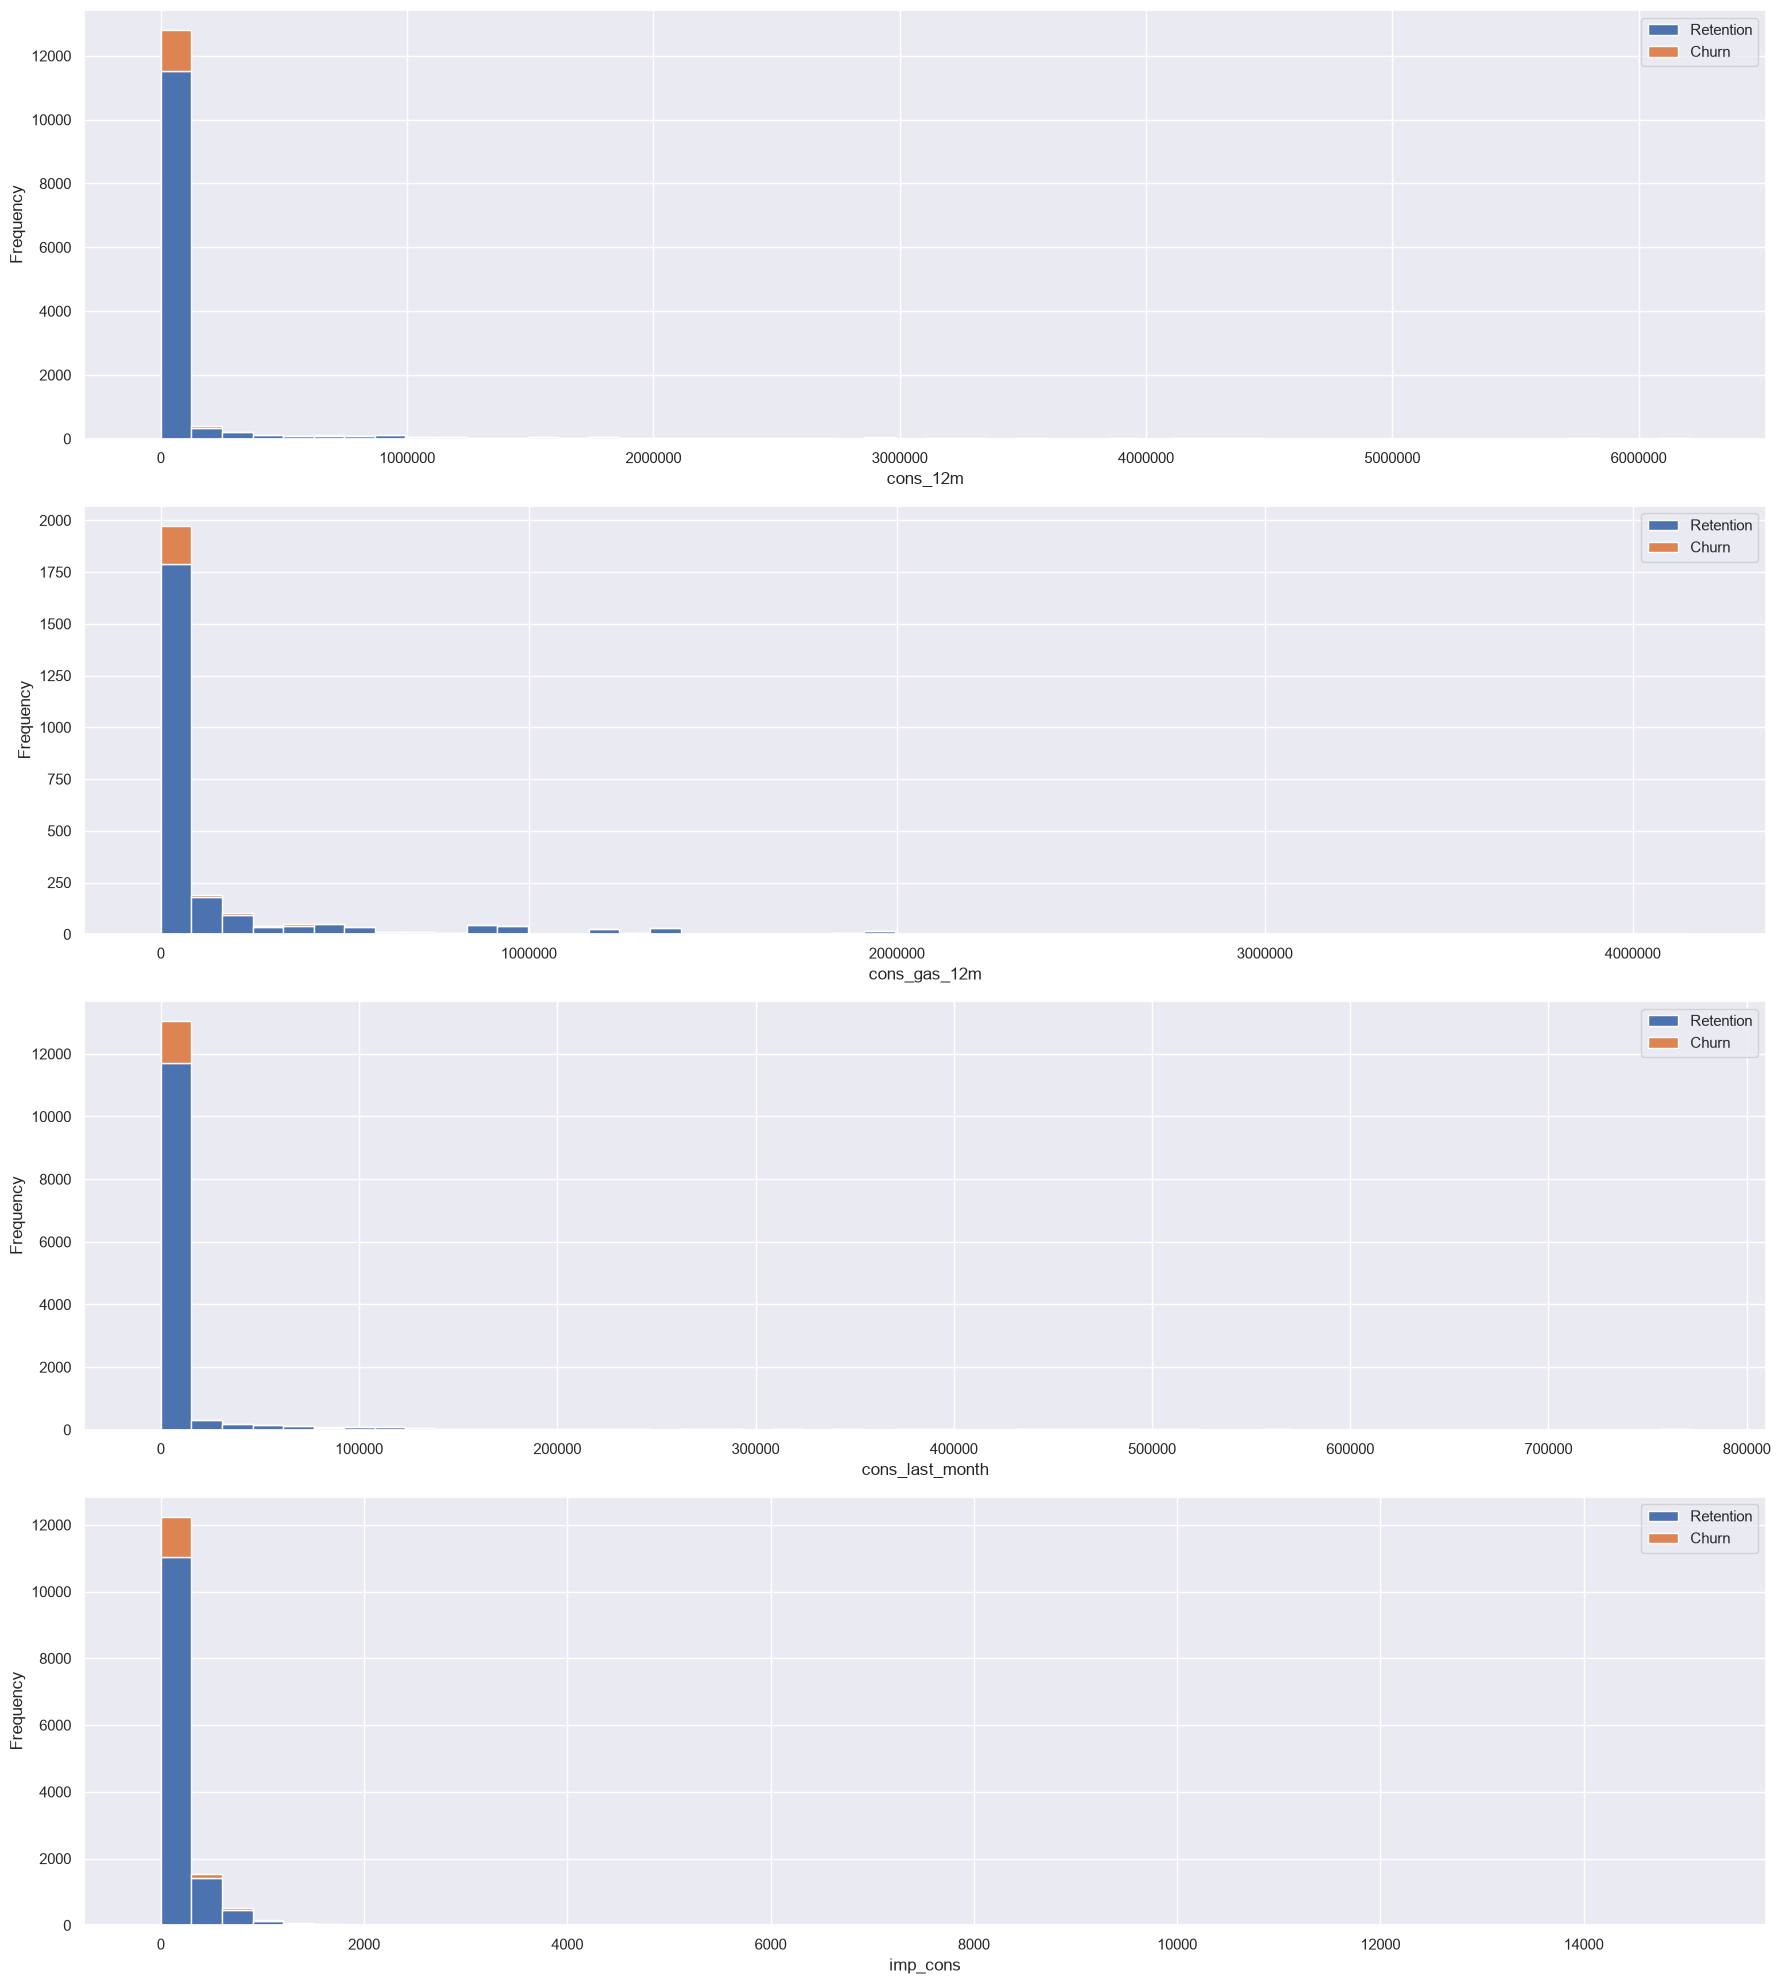

In [30]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=4, figsize=(18, 20))

plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == True], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])
plt.tight_layout()
plt.show()

On a linear scale every consumption variable collapses into a single bar at the left with an
invisible tail stretching to the right — exactly what a skew of 6–13 predicts. The distribution is
unreadable, and so is any difference between churned and retained customers.

Because these values span several orders of magnitude, a **log scale** is the appropriate way to
see the actual shape.

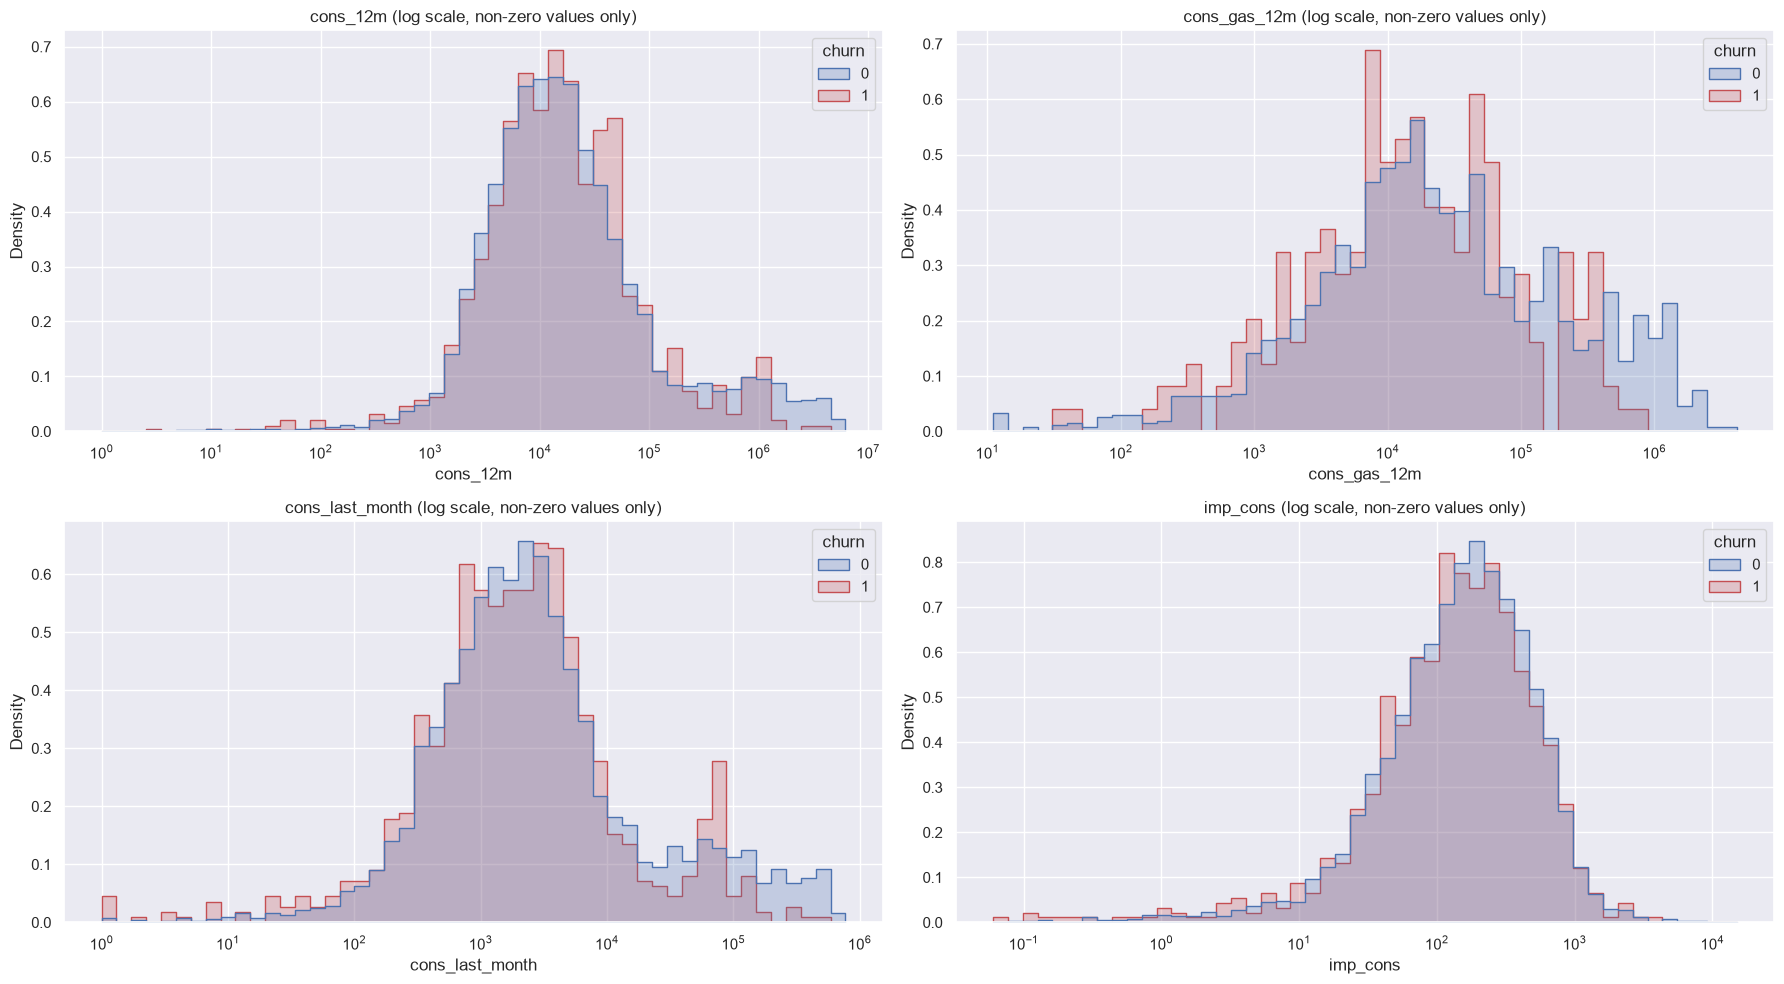

In [31]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

log_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']
for ax, col in zip(axs.ravel(), log_cols):
    data = client_df[client_df[col] > 0]      # log is undefined at 0
    sns.histplot(
        data=data, x=col, hue="churn", bins=50,
        log_scale=True, element="step", stat="density",
        common_norm=False, ax=ax, palette=["#4c72b0", "#c44e52"],
    )
    ax.set_title(f"{col} (log scale, non-zero values only)")

plt.tight_layout()
plt.show()

On a log scale the consumption variables are roughly **log-normal**, which confirms that
`log(1 + x)` is the right transform for modelling.

Normalising each churn group to its own density (`common_norm=False`) shows the two curves sit
almost on top of one another. **Consumption volume on its own barely separates churners from
non-churners** — a large customer is not obviously more or less loyal than a small one. This is an
important negative result: it pushes the search for signal towards *price* and *margin* variables
rather than size.

In [32]:
client_df.groupby("churn")[["cons_12m", "cons_last_month", "imp_cons", "net_margin"]].median().round(1)

,cons_12m,cons_last_month,imp_cons,net_margin
churn,,,,
0,14075.0,800.0,36.7,111.9
1,14529.0,740.0,41.4,121.9


### 6.3 Forecasts

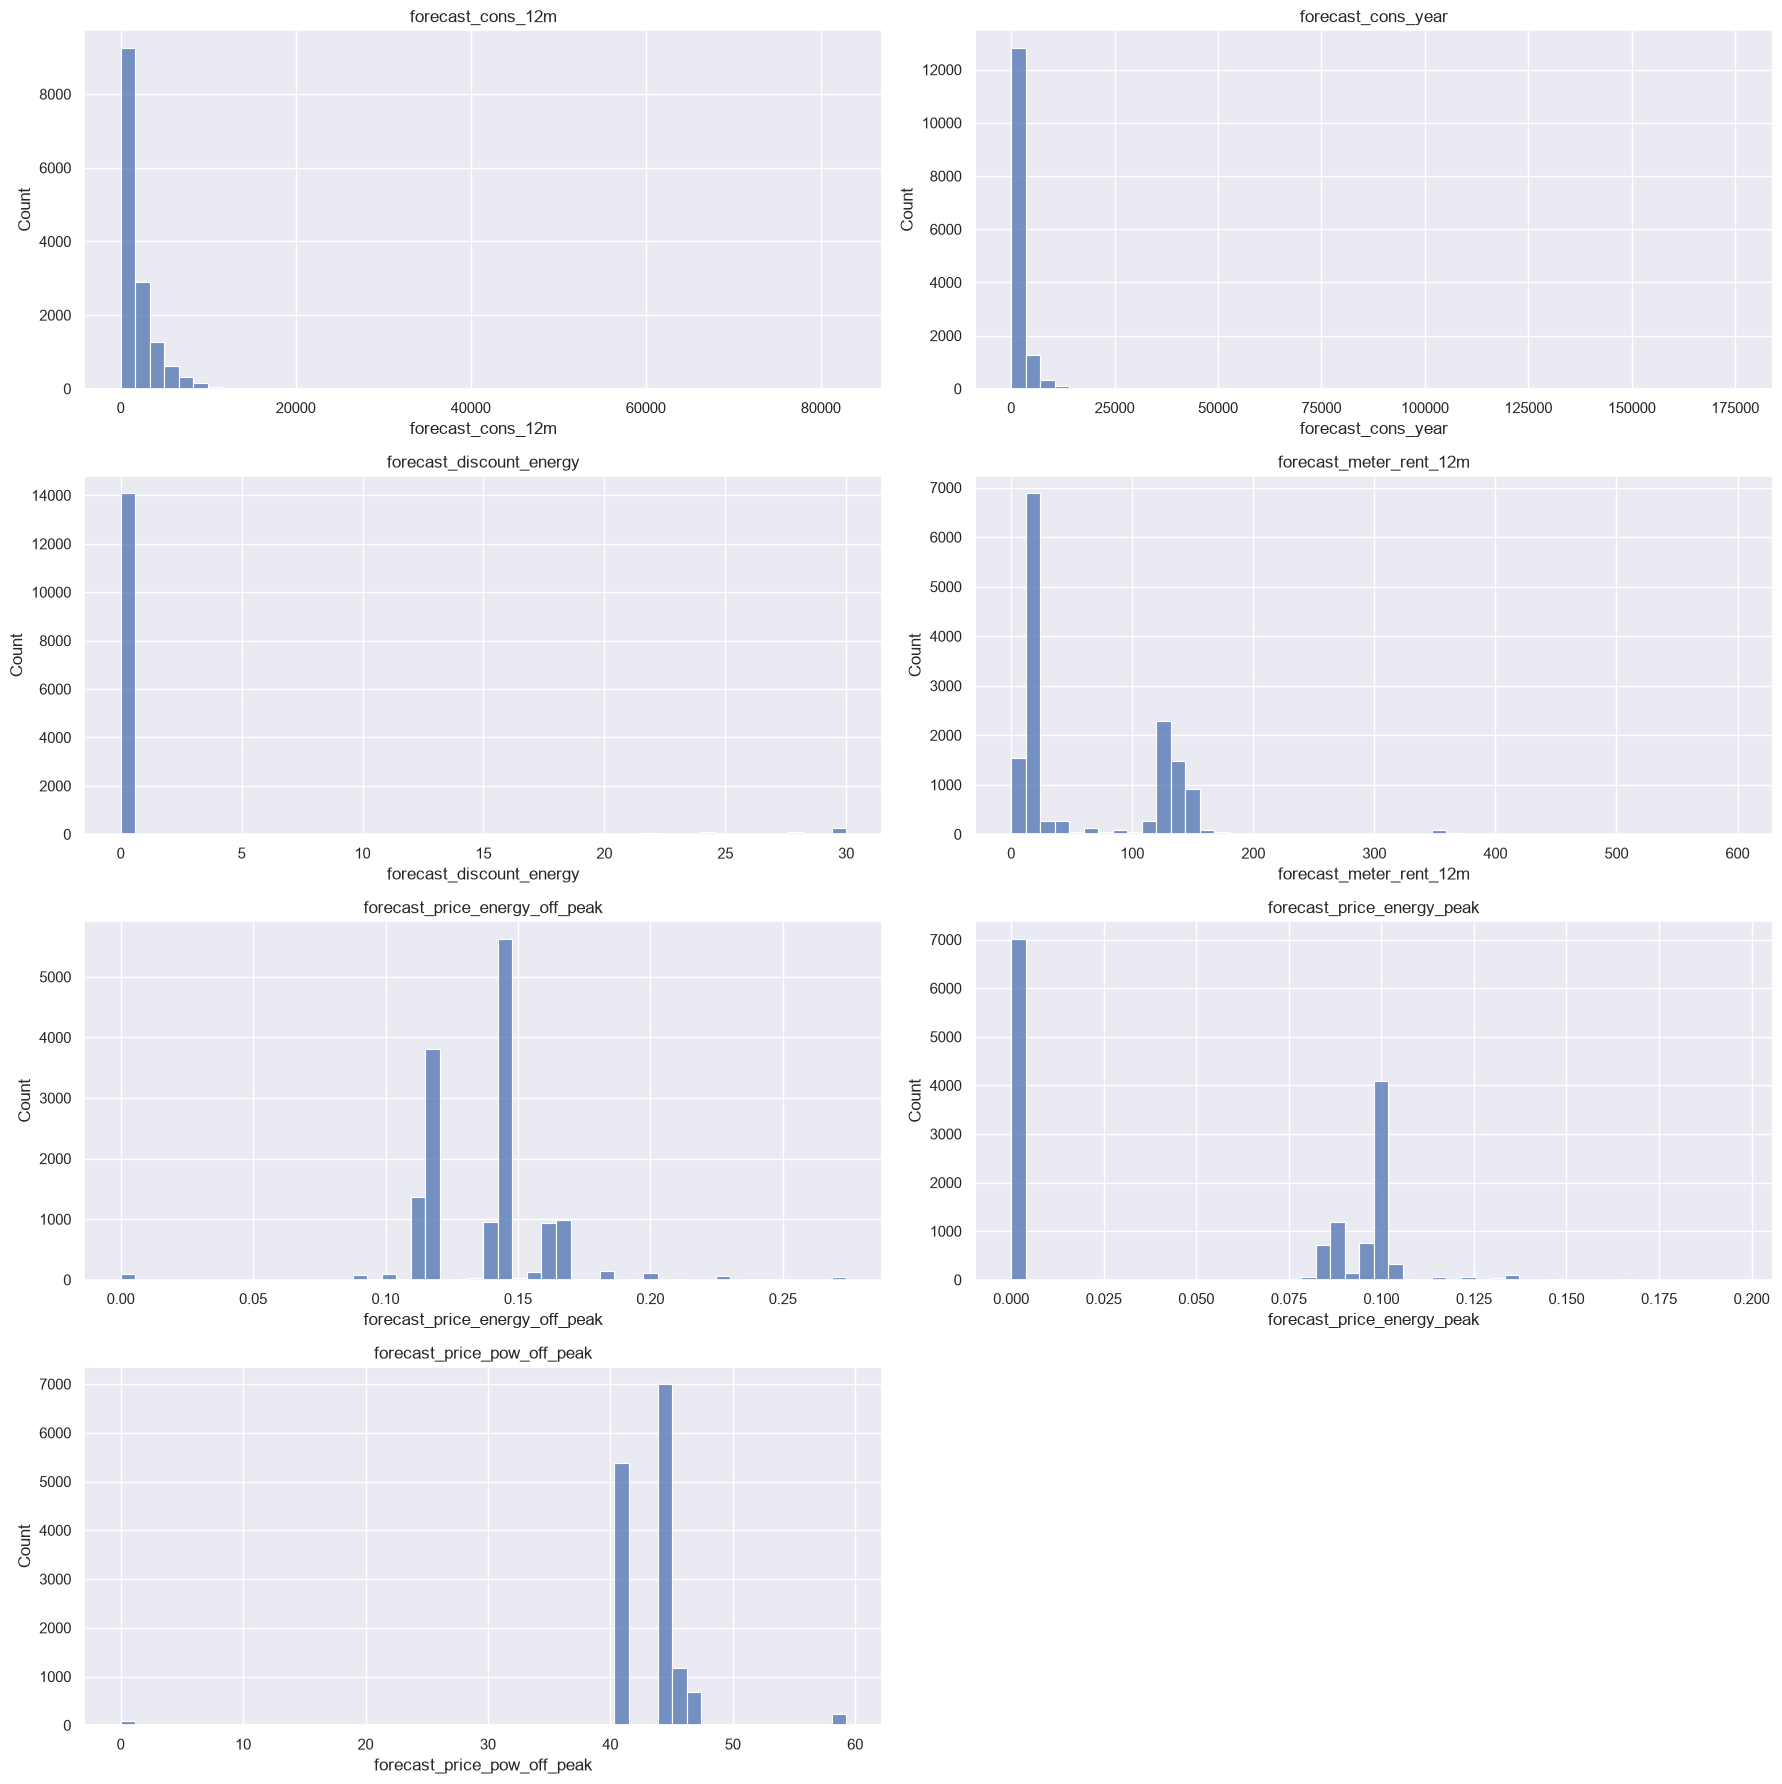

In [33]:
forecast_cols = [
    "forecast_cons_12m", "forecast_cons_year", "forecast_discount_energy",
    "forecast_meter_rent_12m", "forecast_price_energy_off_peak",
    "forecast_price_energy_peak", "forecast_price_pow_off_peak",
]

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(18, 18))
for ax, col in zip(axs.ravel(), forecast_cols):
    sns.histplot(client_df[col], bins=50, ax=ax, color="#4c72b0")
    ax.set_title(col)
    ax.ticklabel_format(style="plain", axis="x")
axs.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

The forecast variables split into two very different shapes:

* **Volume forecasts** (`forecast_cons_12m`, `forecast_cons_year`, `forecast_meter_rent_12m`)
  inherit the same heavy right skew as actual consumption.
* **Price forecasts** are much better behaved. `forecast_price_energy_off_peak` is roughly
  symmetric around €0.14; `forecast_price_pow_off_peak` is tightly clustered near €44 with a
  left tail. `forecast_price_energy_peak` is **bimodal** — a spike at exactly 0 (single-period
  tariff customers) plus a normal-looking bump around €0.10.
* `forecast_discount_energy` is essentially a **near-constant column**: 96.5% zeros, with the
  remaining mass at a handful of discrete levels (30%, 28%, 24%, 22%). It carries almost no
  variance and will be close to useless as a raw predictor.

### 6.4 Margins and subscribed power

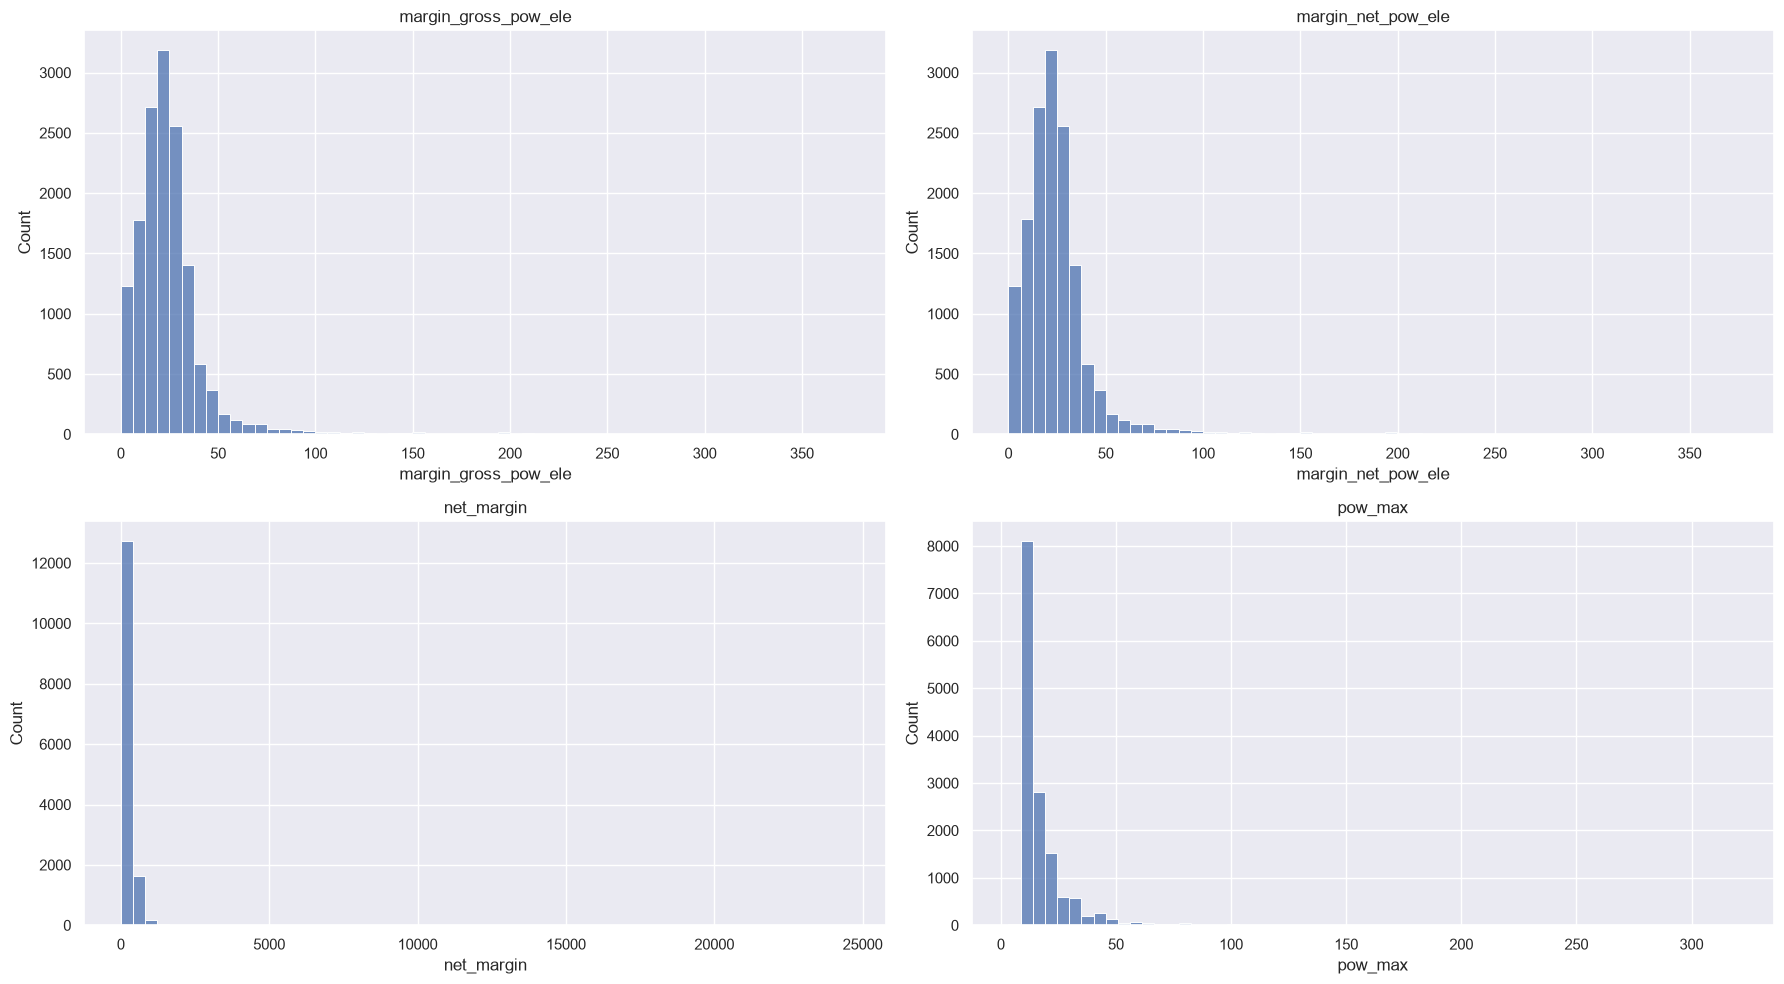

In [34]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

for ax, col in zip(axs.ravel(), ["margin_gross_pow_ele", "margin_net_pow_ele", "net_margin", "pow_max"]):
    sns.histplot(client_df[col], bins=60, ax=ax, color="#4c72b0")
    ax.set_title(col)
    ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

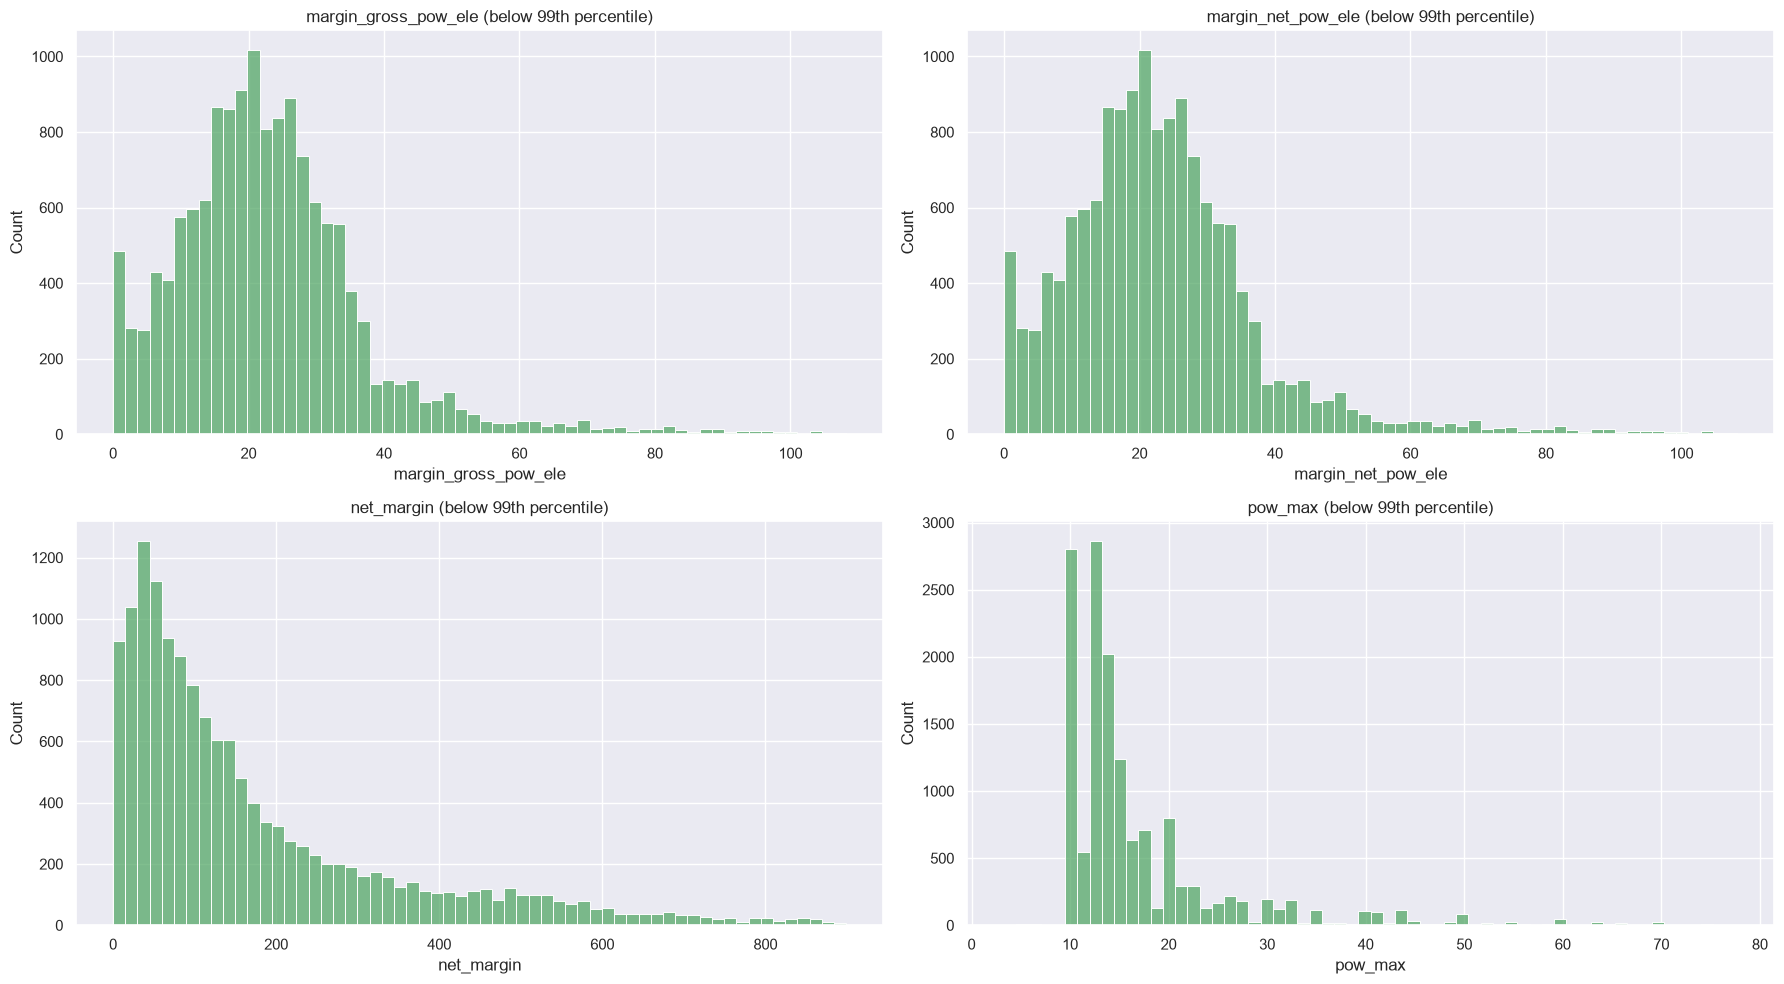

In [35]:
# The same four variables with extreme outliers clipped, so the bulk of the base is visible
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

for ax, col in zip(axs.ravel(), ["margin_gross_pow_ele", "margin_net_pow_ele", "net_margin", "pow_max"]):
    upper = client_df[col].quantile(0.99)
    sns.histplot(client_df.loc[client_df[col] <= upper, col], bins=60, ax=ax, color="#55a868")
    ax.set_title(f"{col} (below 99th percentile)")

plt.tight_layout()
plt.show()

Clipping at the 99th percentile reveals the structure the outliers were hiding:

* The two power margins are **near-identical distributions** — the redundancy we confirmed
  numerically earlier is obvious visually.
* `pow_max` is strongly **multi-modal**, clustering at standard subscribed-power tiers
  (~13.9 kVA is by far the most common). It behaves more like an ordered category than a
  continuous variable.
* `net_margin` remains right-skewed even after clipping — a minority of customers generate a
  disproportionate share of total margin. That has direct commercial consequence: a blanket
  discount would surrender most of its cost on customers who contribute very little margin.

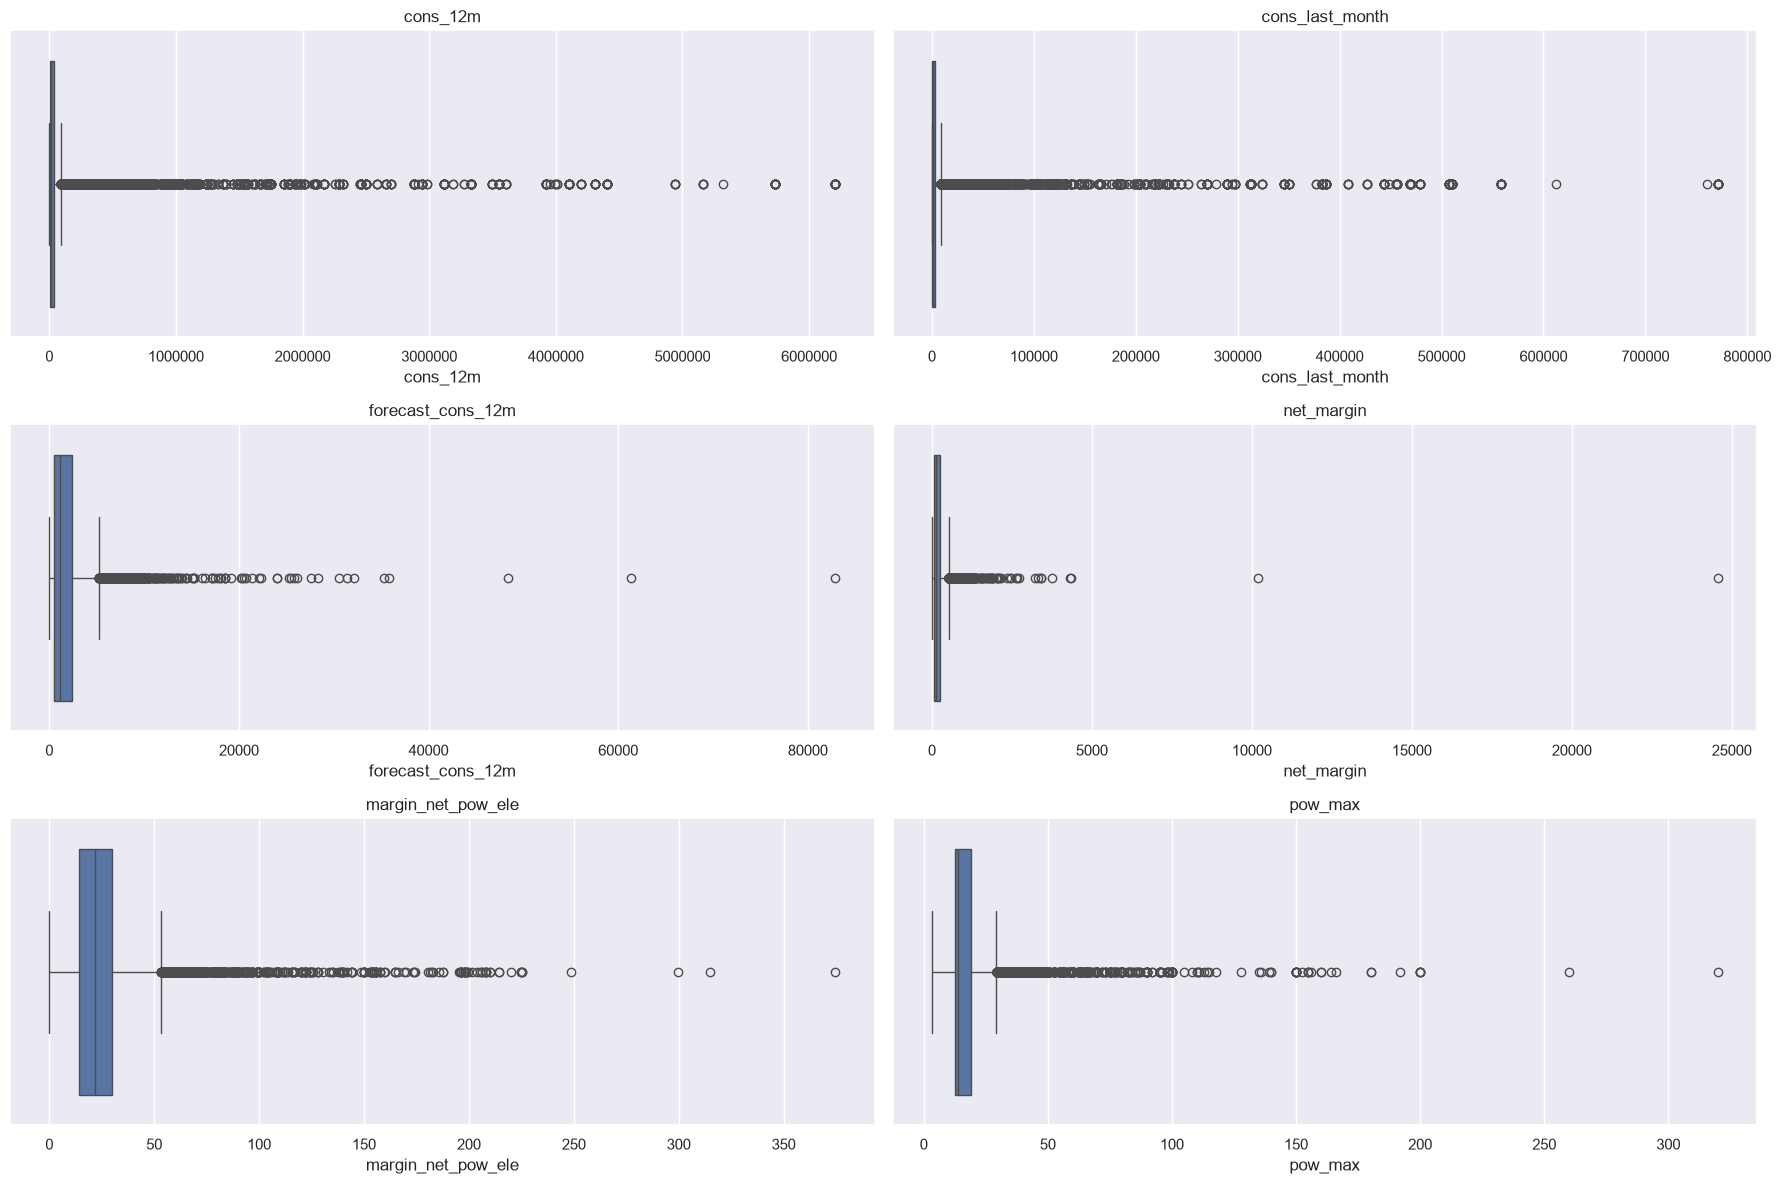

In [36]:
# Boxplots make the outlier problem explicit
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
for ax, col in zip(axs.ravel(), ["cons_12m", "cons_last_month", "forecast_cons_12m",
                                  "net_margin", "margin_net_pow_ele", "pow_max"]):
    sns.boxplot(x=client_df[col], ax=ax, color="#4c72b0")
    ax.set_title(col)
    ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### 6.5 Categorical variables vs churn

In [37]:
def churn_by_category(column, title, size=(12, 6), rot=0, legend="upper right"):
    # Row-normalised stacked bar: share of retained vs churned within each category
    counts = pd.crosstab(client_df[column], client_df["churn"])
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    plot_stacked_bars(pct, title, size_=size, rot_=rot, legend_=legend)
    return counts.assign(total=counts.sum(axis=1),
                         churn_rate_pct=(counts[1] / counts.sum(axis=1) * 100).round(1))

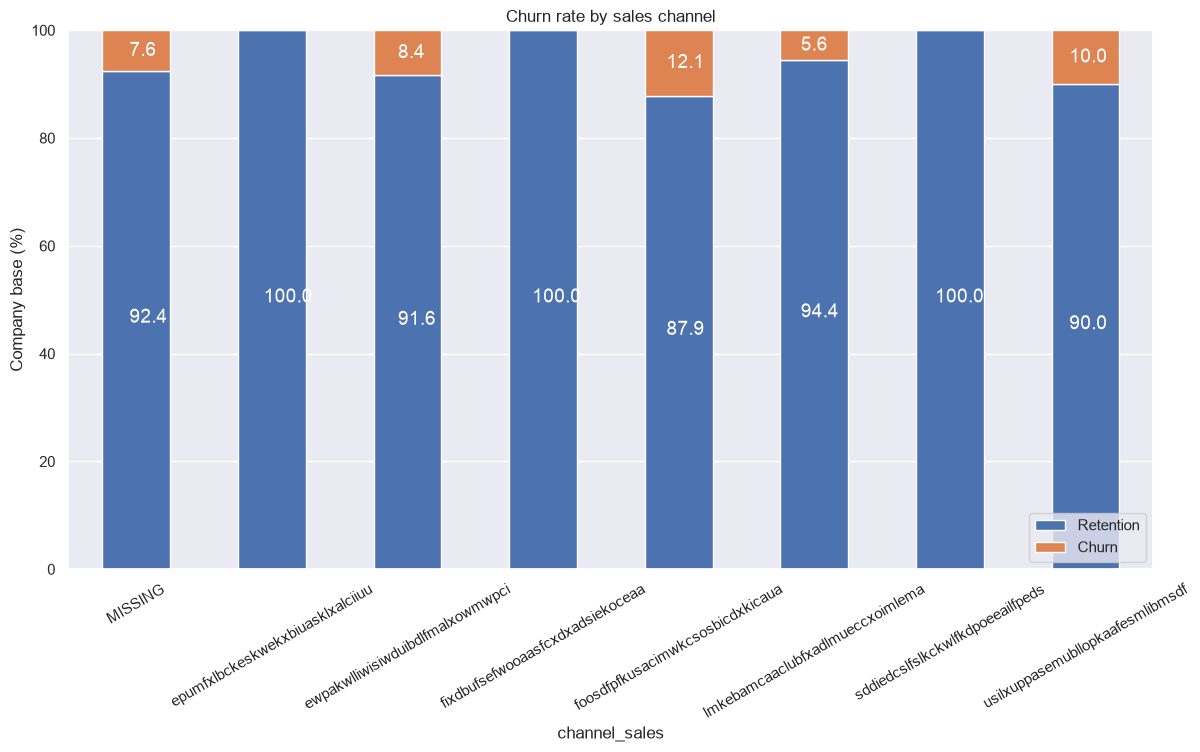

churn,0,1,total,churn_rate_pct
channel_sales,,,,
MISSING,3442,283,3725,7.6
epumfxlbckeskwekxbiuasklxalciiuu,3,0,3,0.0
ewpakwlliwisiwduibdlfmalxowmwpci,818,75,893,8.4
fixdbufsefwooaasfcxdxadsiekoceaa,2,0,2,0.0
foosdfpfkusacimwkcsosbicdxkicaua,5934,820,6754,12.1
lmkebamcaaclubfxadlmueccxoimlema,1740,103,1843,5.6
sddiedcslfslkckwlfkdpoeeailfpeds,11,0,11,0.0
usilxuppasemubllopkaafesmlibmsdf,1237,138,1375,10.0


In [38]:
churn_by_category("channel_sales", "Churn rate by sales channel", size=(14, 7), rot=30, legend="lower right")

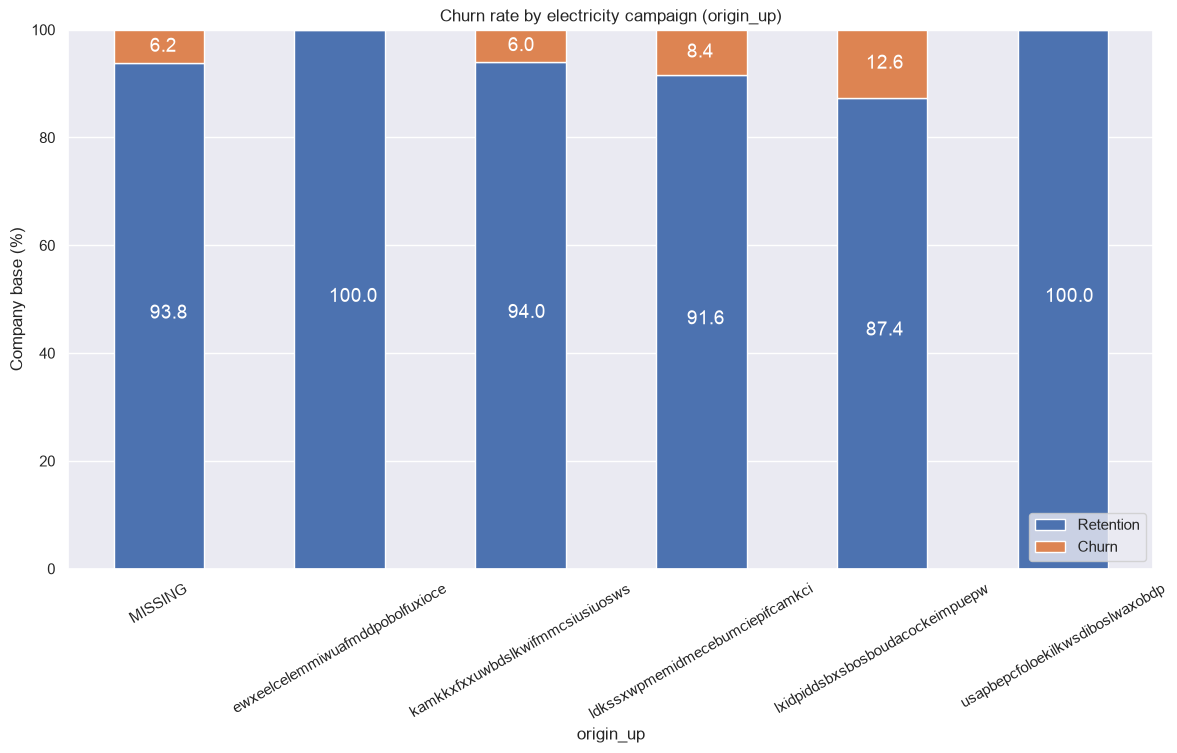

churn,0,1,total,churn_rate_pct
origin_up,,,,
MISSING,60,4,64,6.2
ewxeelcelemmiwuafmddpobolfuxioce,1,0,1,0.0
kamkkxfxxuwbdslkwifmmcsiusiuosws,4036,258,4294,6.0
ldkssxwpmemidmecebumciepifcamkci,2884,264,3148,8.4
lxidpiddsbxsbosboudacockeimpuepw,6204,893,7097,12.6
usapbepcfoloekilkwsdiboslwaxobdp,2,0,2,0.0


In [39]:
churn_by_category("origin_up", "Churn rate by electricity campaign (origin_up)", size=(14, 7), rot=30, legend="lower right")

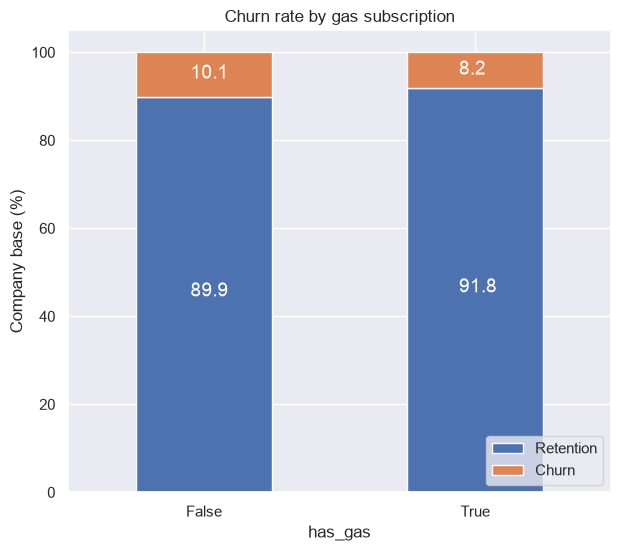

churn,0,1,total,churn_rate_pct
has_gas,,,,
False,10753,1202,11955,10.1
True,2434,217,2651,8.2


In [40]:
churn_by_category("has_gas", "Churn rate by gas subscription", size=(7, 6), legend="lower right")

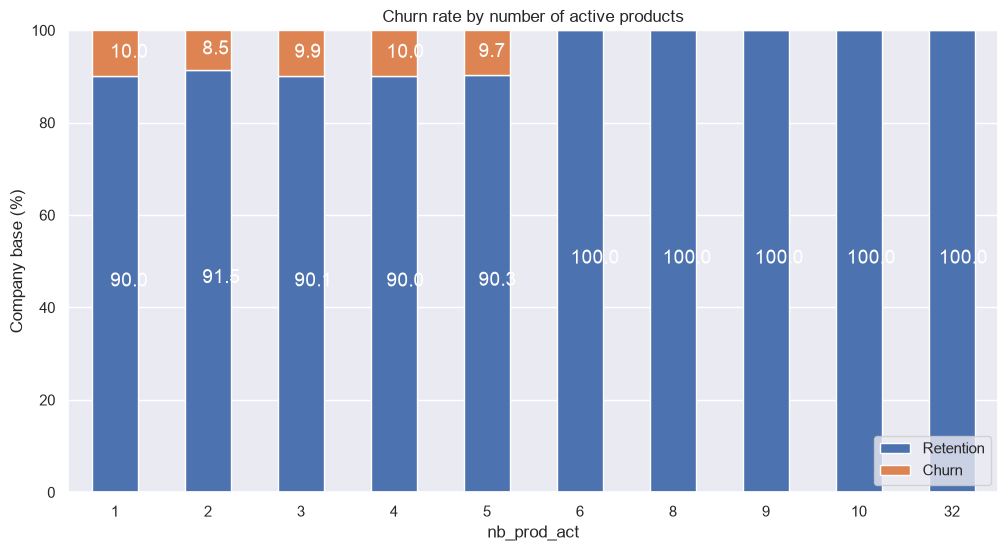

churn,0,1,total,churn_rate_pct
nb_prod_act,,,,
1,10290,1141,11431,10.0
2,2237,208,2445,8.5
3,471,52,523,9.9
4,135,15,150,10.0
5,28,3,31,9.7
6,8,0,8,0.0
8,4,0,4,0.0
9,11,0,11,0.0
10,2,0,2,0.0


In [41]:
churn_by_category("nb_prod_act", "Churn rate by number of active products", size=(12, 6), legend="lower right")

`nb_prod_act` is stored as an integer, but the cardinality check showed only **10 distinct
values** — it behaves as an ordered category, not a continuous measurement, which is why it gets
a stacked bar here rather than a histogram.

The result is a **negative one, plus a denominator trap**. Churn sits flat around the 9.7%
baseline for 1–5 products (9.98%, 8.51%, 9.94%, 10.0%, 9.68%), so the number of products a
customer holds barely moves their churn risk. The groups showing 0% churn (6, 8, 9, 10 and 32
products) hold **between 1 and 11 customers each** — the same noise pattern as the rare sales
channels, and not a finding.

**Observations — read these against the 9.7% baseline, and always alongside the group size.**

* **Sales channel matters.** The largest channel, `foosdfpf...` (6,754 clients, 46% of the base),
  churns at **12.1%** — well above baseline. `lmkebamc...` churns at only 5.6%. Clients with a
  `MISSING` channel churn at 7.6%, so the missingness itself is informative and should be kept as
  its own level rather than imputed away.
* **Acquisition campaign matters.** `lxidpidd...` (7,097 clients) churns at **12.6%** versus 6.0%
  for `kamkkxfx...` — a 2x spread across the two biggest campaigns.
* Three channels and two campaigns show 0% churn, but each has **1–11 clients**. These are noise,
  not findings, and are a good argument for grouping rare levels into an "Other" bucket before
  modelling.
* **Dual-fuel customers are stickier**: 8.2% churn for gas customers vs 10.1% for electricity-only.
  The effect is real but modest.

### 6.6 Contract dates and tenure

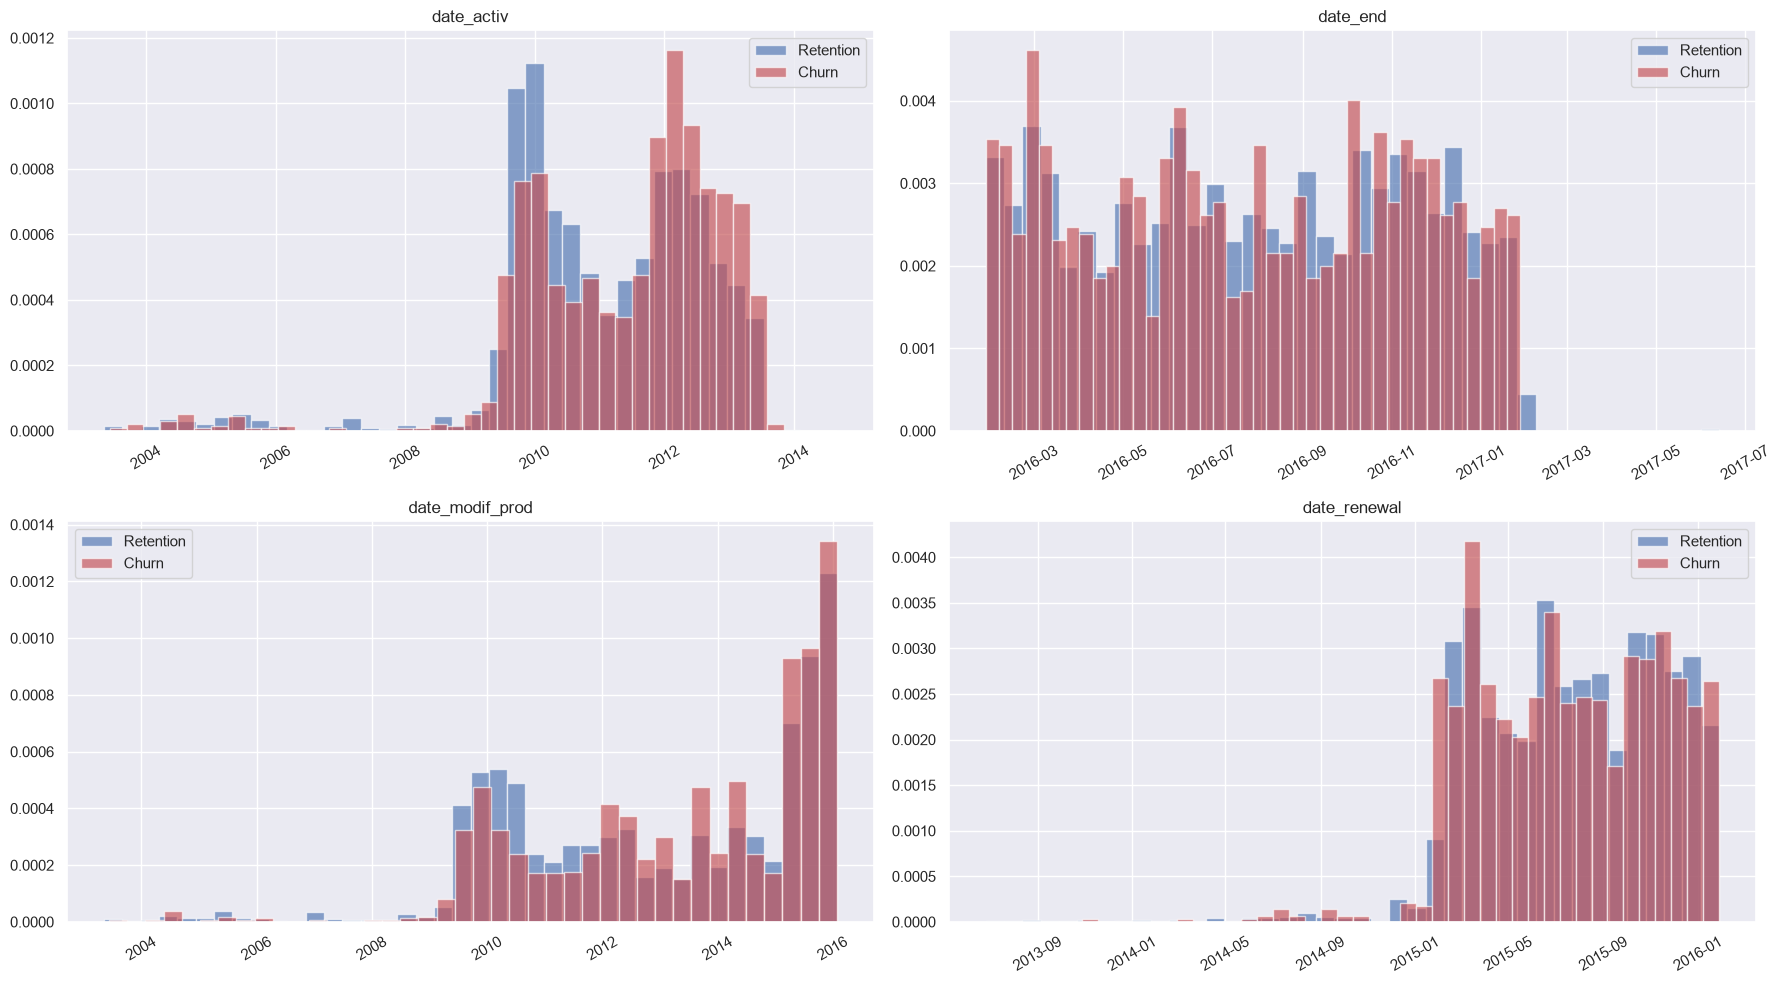

In [42]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
for ax, col in zip(axs.ravel(), date_columns):
    for label, colour in [(0, "#4c72b0"), (1, "#c44e52")]:
        subset = client_df.loc[client_df["churn"] == label, col]
        ax.hist(subset, bins=40, alpha=0.65, color=colour,
                label="Churn" if label else "Retention", density=True)
    ax.set_title(col)
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [43]:
client_df["tenure_days"] = (client_df["date_end"] - client_df["date_activ"]).dt.days
client_df.groupby("churn")["tenure_days"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,13187.0,2022.204065,605.783266,731.0,1461.0,1933.0,2410.5,4795.0
1,1419.0,1871.239605,579.071742,979.0,1461.0,1827.0,2192.0,4749.0


Customers who churned had slightly **shorter tenure** than retained customers. The median tenure
was **1,827 days** for churned customers compared with **1,933 days** for retained customers — a
difference of 106 days. Customer tenure may therefore be a useful feature for churn modelling,
although this result alone does not establish that tenure *causes* churn.

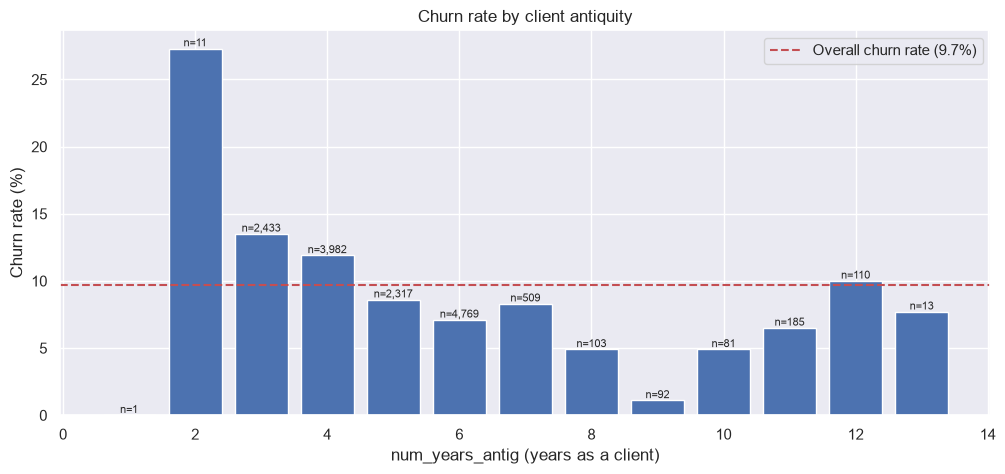

,churn_rate_pct,size
num_years_antig,,
1,0.0,1
2,27.3,11
3,13.5,2433
4,11.9,3982
5,8.6,2317
6,7.1,4769
7,8.3,509
8,4.9,103
9,1.1,92


In [44]:
tenure = client_df.groupby("num_years_antig")["churn"].agg(["mean", "size"])
tenure["churn_rate_pct"] = (tenure["mean"] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tenure.index, tenure["churn_rate_pct"], color="#4c72b0")
ax.axhline(client_df["churn"].mean() * 100, color="#c44e52", linestyle="--",
           label=f"Overall churn rate ({client_df['churn'].mean()*100:.1f}%)")
for x, (rate, n) in zip(tenure.index, tenure[["churn_rate_pct", "size"]].values):
    ax.annotate(f"n={int(n):,}", (x, rate), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("num_years_antig (years as a client)")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by client antiquity")
ax.legend()
plt.show()

tenure[["churn_rate_pct", "size"]]

Churn declines fairly steadily with antiquity across the years that hold real volume:
**13.5% at 3 years → 11.9% at 4 → 8.6% at 5 → 7.1% at 6**. Beyond year 7 the groups shrink to
a few hundred clients or fewer and the rate becomes noisy (the 27% at 2 years is 3 churners out of
11 clients — not a finding).

The useful, well-supported signal is that **newer customers are the flight risk**, which is
consistent with a price-sensitivity story: clients who joined recently are the ones still actively
comparing offers.

### 6.7 Prices over time

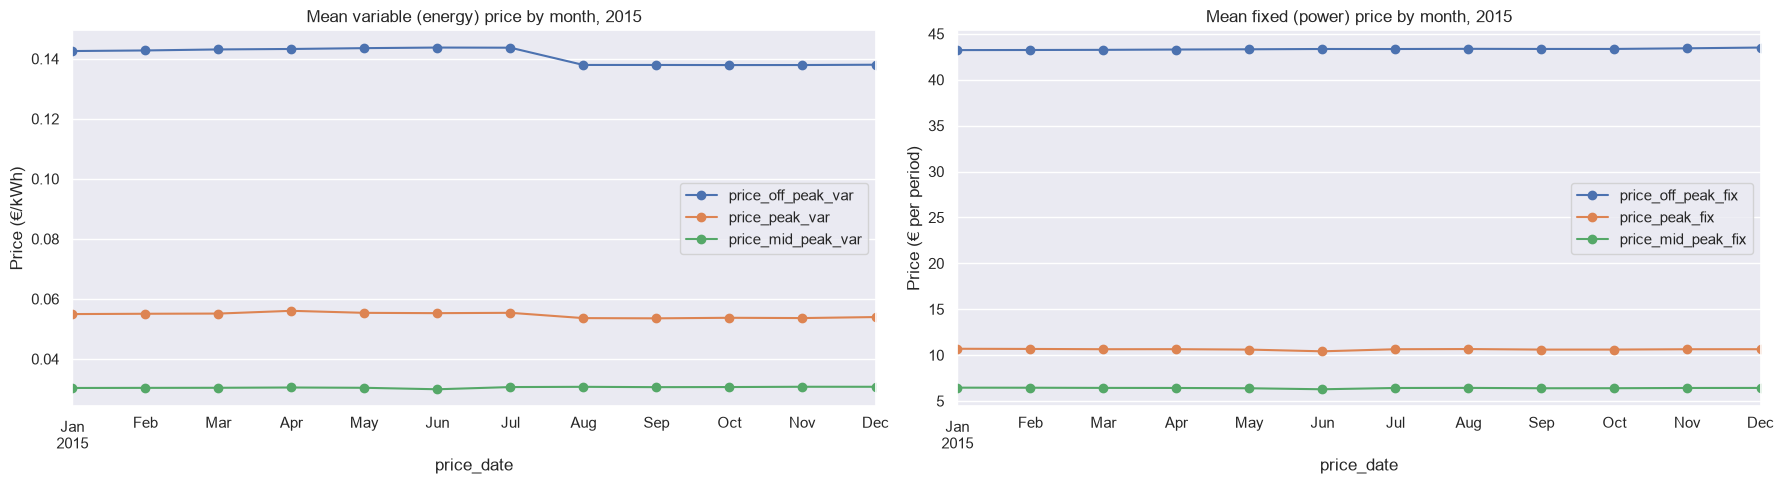

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
price_date,,,,,,
2015-01-01,0.1426,0.0550,0.0303,43.2266,10.6929,6.4559
2015-02-01,0.1428,0.0551,0.0304,43.2382,10.6737,6.4490
2015-03-01,0.1431,0.0551,0.0304,43.2540,10.6445,6.4301
2015-04-01,0.1433,0.0560,0.0305,43.2884,10.6473,6.4232
2015-05-01,0.1435,0.0554,0.0304,43.3154,10.6025,6.3908
2015-06-01,0.1437,0.0553,0.0299,43.3473,10.4158,6.2813
2015-07-01,0.1437,0.0554,0.0306,43.3450,10.6422,6.4215
2015-08-01,0.1379,0.0536,0.0307,43.3654,10.6617,6.4315
2015-09-01,0.1379,0.0535,0.0306,43.3519,10.6030,6.3918


In [45]:
monthly = price_df.groupby("price_date")[price_var_cols + price_fix_cols].mean()

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

monthly[price_var_cols].plot(ax=axs[0], marker="o")
axs[0].set_title("Mean variable (energy) price by month, 2015")
axs[0].set_ylabel("Price (€/kWh)")

monthly[price_fix_cols].plot(ax=axs[1], marker="o")
axs[1].set_title("Mean fixed (power) price by month, 2015")
axs[1].set_ylabel("Price (€ per period)")

plt.tight_layout()
plt.show()
monthly.round(4)

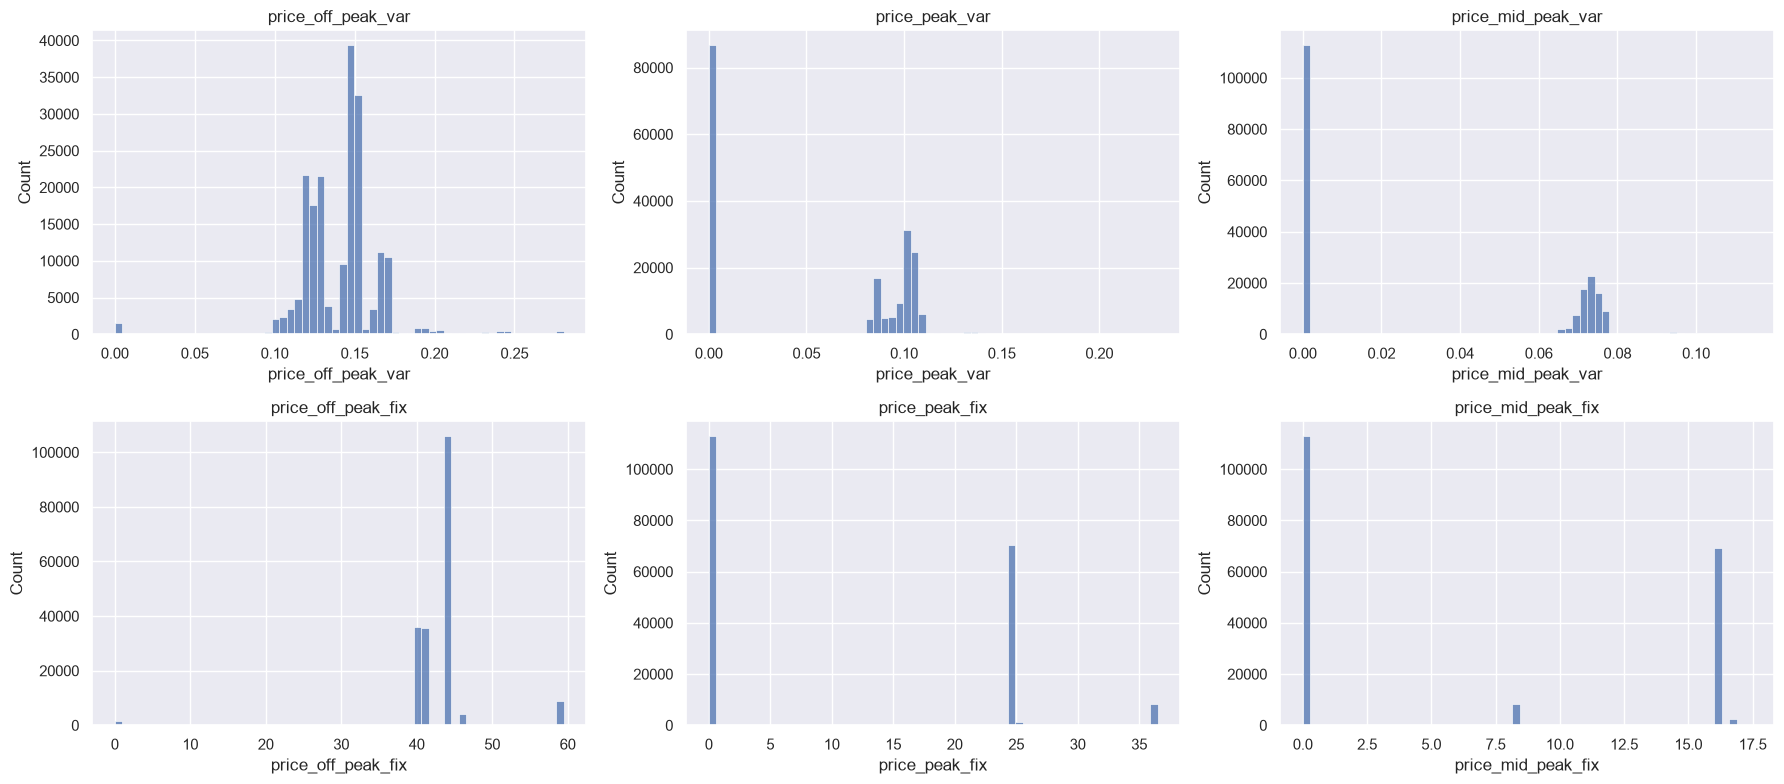

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
for ax, col in zip(axs.ravel(), price_var_cols + price_fix_cols):
    sns.histplot(price_df[col], bins=60, ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observations**

* Average price levels are **remarkably flat across 2015** — the mean off-peak energy price barely
  moves. There is no market-wide price shock in this window.
* That is exactly why *cross-sectional* and *within-customer* price variation is the interesting
  thing, not the time trend. Two customers in the same month can face materially different prices.
* Every price distribution is **multi-modal with a large spike at zero** — the signature of a small
  number of discrete tariff structures rather than a continuous price surface. Customers cluster
  onto a handful of tariffs.

In [47]:
# Preview of the price-sensitivity hypothesis: aggregate 2015 prices to customer level
price_agg = price_df.groupby("id")[price_var_cols + price_fix_cols].agg(["mean", "std"])
price_agg.columns = [f"{c}_{stat}" for c, stat in price_agg.columns]

merged = client_df[["id", "churn"]].merge(price_agg, on="id", how="left")
merged.groupby("churn")[[
    "price_off_peak_var_mean", "price_off_peak_var_std",
    "price_peak_var_mean", "price_off_peak_fix_mean", "price_off_peak_fix_std",
]].mean().round(5)

,price_off_peak_var_mean,price_off_peak_var_std,price_peak_var_mean,price_off_peak_fix_mean,price_off_peak_fix_std
churn,,,,,
0,0.14237,0.00401,0.05158,42.90381,0.18232
1,0.14189,0.00464,0.05656,43.16194,0.24707


This is only a first look, but it is directionally interesting: churned customers face a very
similar **average** price to retained customers, while differing slightly in **price variability**
(the standard deviation of their 2015 prices).

That supports the direction the case is pushing towards — it is unlikely to be the raw price level
that drives churn, but rather **how a customer's price has *changed*** (e.g. December vs January
difference, off-peak vs peak spread, volatility). Constructing those derived price features is the
job of the next task; the aggregation above is deliberately left as a preview rather than a
finished feature set.

### 6.8 Correlations

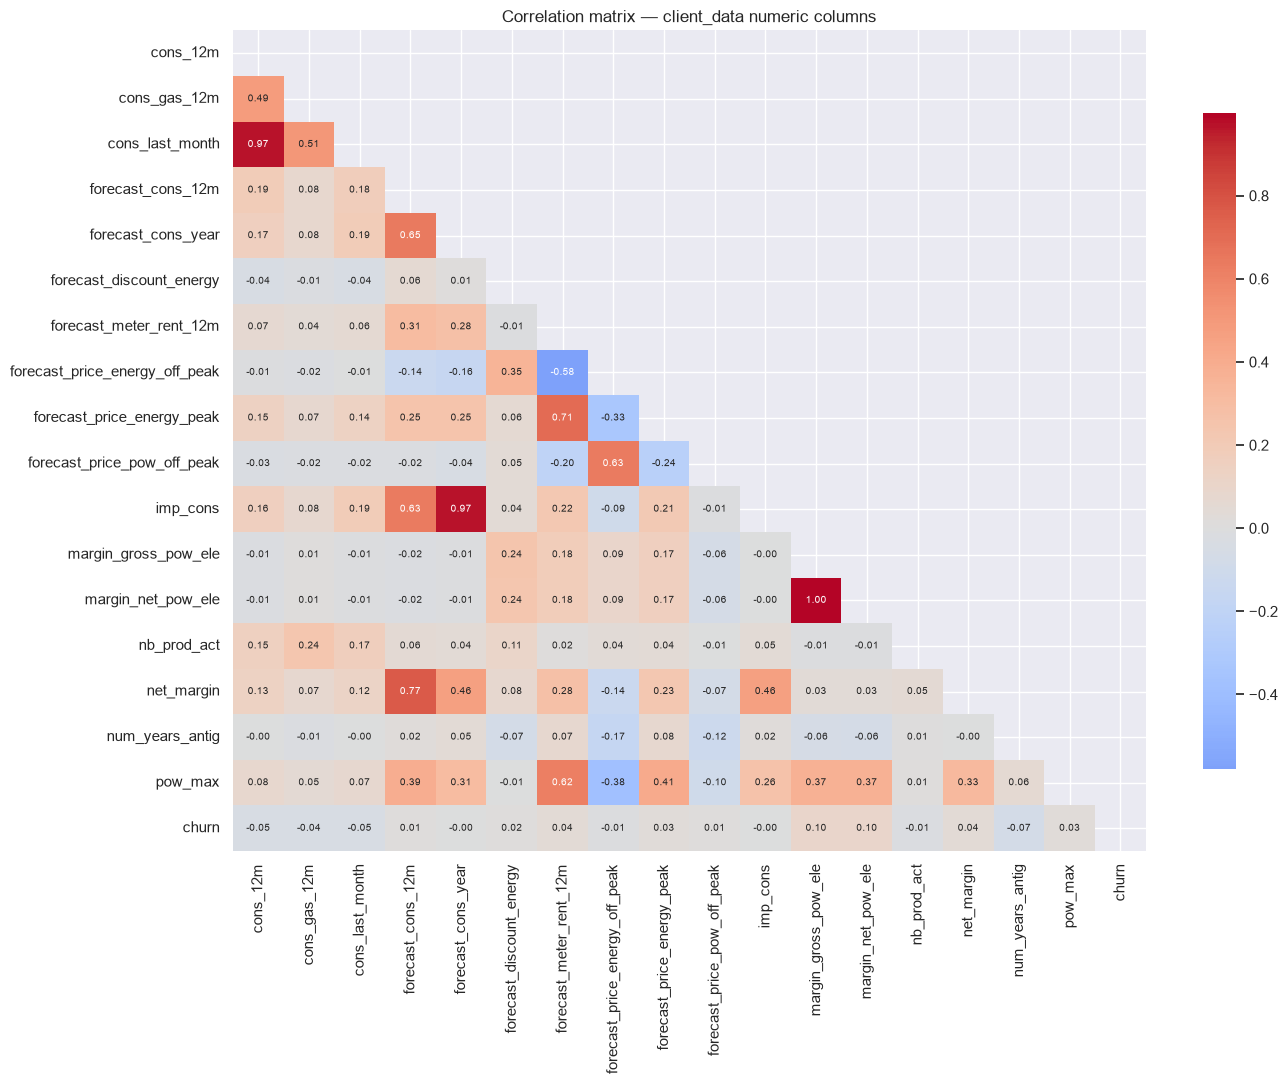

In [48]:
corr = client_df[numeric_cols + ["churn"]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — client_data numeric columns")
plt.tight_layout()
plt.show()

In [49]:
corr["churn"].drop("churn").sort_values(key=abs, ascending=False).round(3).to_frame("corr_with_churn")

,corr_with_churn
margin_net_pow_ele,0.096
margin_gross_pow_ele,0.096
num_years_antig,-0.074
cons_12m,-0.046
cons_last_month,-0.045
forecast_meter_rent_12m,0.044
net_margin,0.041
cons_gas_12m,-0.038
pow_max,0.030
forecast_price_energy_peak,0.029


**Observations**

* **No single numeric variable is strongly correlated with churn** — the largest absolute
  correlation is small. Churn will not be predicted by any one column; it will need engineered
  features and a non-linear model.
* There are strong correlations *between predictors*, which is the more actionable finding here:
  * `margin_gross_pow_ele` ↔ `margin_net_pow_ele` — effectively the same column (ρ ≈ 1.00).
  * `cons_12m` ↔ `cons_last_month` ↔ `imp_cons` ↔ `forecast_cons_12m` — the consumption family all
    measures customer size.
  * `pow_max` correlates with the consumption family, as expected.
* This multicollinearity needs handling before fitting anything with linear coefficients; a
  tree-based model tolerates it but will split the importance across the correlated group.

---

## 7. Summary of findings

### What the data is

| | `client_data.csv` | `price_data.csv` |
|---|---|---|
| Grain | one row per client | one row per client per month |
| Rows | 14,606 | 193,002 |
| Columns | 26 (incl. the `churn` target) | 8 |
| Coverage | snapshot, contracts activated 2003–2014 | calendar year 2015, monthly |
| Join key | `id` | `id` |

All 14,606 modellable clients have price history. The price file carries ~1,490 extra companies
with no churn label. The price panel sits **before** the churn outcome window, so there is no
obvious leakage.

### Data quality issues to fix before modelling

1. **Encoded missingness.** No `NaN` anywhere, but `channel_sales` is `"MISSING"` for 25.5% of
   clients and `origin_up` for 0.4%. Keep as an explicit level — the missingness itself is
   predictive (7.6% churn vs 9.7% baseline).
2. **Wrong dtypes.** Four date columns arrive as text; `has_gas` arrives as `'t'`/`'f'`. Both cast
   cleanly.
3. **Extreme skew.** Consumption, forecast and margin columns have skew of 4–37 and max/median
   ratios up to 440x. Requires log transformation and/or outlier capping.
4. **Redundant column.** `margin_gross_pow_ele` and `margin_net_pow_ele` are identical in 99.99%
   of rows — drop one.
5. **Near-constant column.** `forecast_discount_energy` is zero for 96.5% of clients.
6. **Structural zeros.** Zeros in `cons_gas_12m`, `price_peak_*` and `price_mid_peak_*` mean "not
   applicable" (no gas contract / single-period tariff), not "unknown". They should be flagged, not
   imputed.
7. **Rare categories.** Several `channel_sales` and `origin_up` levels have fewer than 12 clients
   and show 0% churn — pure noise. Group into "Other".
8. **Missing field.** The data description lists `activity_new`, which is absent from the delivered
   file. Worth raising with the client.

### What drives churn — early signals

* Churn is **9.7%**, i.e. a **90/10 class imbalance**. Evaluate on recall/precision/F1 and the
  confusion matrix, never accuracy alone.
* **Consumption volume barely separates the two groups** — customer size is not the story.
* **Sales channel** and **acquisition campaign** show the clearest raw separation: 12.1% vs 5.6%
  churn across the two biggest channels, and 12.6% vs 6.0% across the two biggest campaigns.
* **Newer customers churn more**: 13.5% at 3 years' antiquity falling to 7.1% at 6 years.
* **Dual-fuel customers are stickier** (8.2% vs 10.1%).
* **No single numeric variable correlates strongly with churn**, and average price levels are flat
  across 2015 and near-identical between churners and non-churners.

### Implication for the price-sensitivity hypothesis

The raw data does **not** support a simple "high price → churn" story: churned and retained
customers face almost the same average 2015 prices. What differs slightly is **price
variability**. That points the next task at derived price features — off-peak vs peak spreads,
December-versus-January price differences, and within-year volatility — rather than at price
levels.

### Next steps

1. Engineer per-customer price features from the 2015 panel (differences, spreads, volatility).
2. Clean and transform: cast dtypes, handle `"MISSING"`, log-transform skewed columns, cap
   outliers, drop the redundant margin column, group rare categories.
3. Build a churn model with class-imbalance handling, and evaluate on recall/precision/F1.
4. Only then assess whether a targeted 20% discount is margin-accretive for the highest-risk,
   highest-value segment.